Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔬 Iniciando Auditoría Forense Universal sobre: /content/drive/MyDrive/bt/ARC_MASTER_DATA.csv
🔍 Columnas detectadas en el Master: ['Timestamp', 'Price', 'Node_M2', 'Node_Int', 'Sexto', 'Energy', 'Action', 'Tier_Predicted', 'Profit_Hyp', 'SL_Distance', 'Drawdown', 'InGloria', 'InPoder']
📊 Procesando millones de registros... por favor espera.


/tmp/ipython-input-1889144155.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"Sexto {int(k)}" for k in keys], y=[stats_sexto[k] for k in keys], ax=ax[0], palette='viridis')


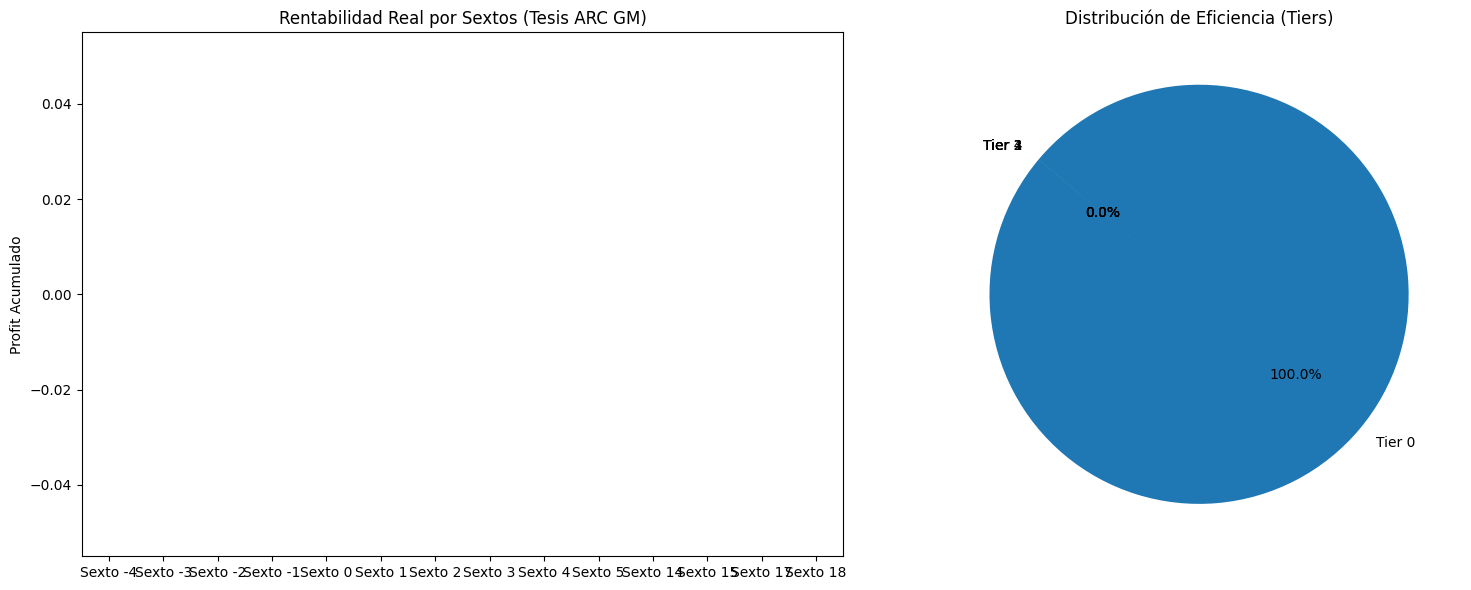


💰 RESUMEN AUDITORÍA: Profit Total Detectado = 0.00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. CONEXIÓN A GOOGLE DRIVE
drive.mount('/content/drive')

# --- CONFIGURACIÓN DE RUTA ---
# Asegúrate de que la carpeta y el nombre coincidan con tu Drive
PATH = '/content/drive/MyDrive/bt/'
FILE_NAME = 'ARC_MASTER_DATA.csv'
FILE_PATH = os.path.join(PATH, FILE_NAME)

def universal_arc_auditor(file_path):
    print(f"🔬 Iniciando Auditoría Forense Universal sobre: {file_path}")

    if not os.path.exists(file_path):
        print(f"❌ Error: Archivo no encontrado en {file_path}")
        return

    # 1. INSPECCIÓN AUTOMÁTICA DE COLUMNAS
    sample = pd.read_csv(file_path, nrows=10)
    sample.columns = [c.strip() for c in sample.columns]
    cols = sample.columns.tolist()
    print(f"🔍 Columnas detectadas en el Master: {cols}")

    # Mapeo inteligente de datos
    col_node = next((c for c in cols if c in ['NM2', 'Node_M2', 'Node_Int']), None)
    col_profit = next((c for c in cols if c in ['Profit_Hyp', 'Profit']), None)
    col_entry = next((c for c in cols if c in ['Entry', 'Entry_Price', 'Price']), None)
    col_peak = next((c for c in cols if c in ['Peak_Price', 'MaxPrice']), None)
    col_tier = next((c for c in cols if 'Tier' in c), None)
    col_sexto = next((c for c in cols if 'Sexto' in c), None)

    # 2. PROCESAMIENTO POR BLOQUES (Optimizado para 2GB)
    chunk_size = 250000
    stats_sexto = {}
    stats_tier = {}

    reader = pd.read_csv(file_path, chunksize=chunk_size, low_memory=False)

    print("📊 Procesando millones de registros... por favor espera.")

    for i, chunk in enumerate(reader):
        chunk.columns = [c.strip() for c in chunk.columns]

        # A. CÁLCULO DE PROFIT (Si no existe la columna, se calcula)
        if col_profit:
            p_series = pd.to_numeric(chunk[col_profit], errors='coerce').fillna(0)
        elif col_entry and col_peak:
            # En la versión Miner, el profit es la diferencia absoluta entre el pico y la entrada
            p_series = (pd.to_numeric(chunk[col_peak], errors='coerce') -
                        pd.to_numeric(chunk[col_entry], errors='coerce')).abs().fillna(0)
        else:
            p_series = pd.Series(0, index=chunk.index)

        # B. CÁLCULO DE SEXTO (Si no existe, se deriva del Nodo)
        if col_sexto:
            s_series = chunk[col_sexto]
        elif col_node:
            # Fórmula ARC GM: Sexto = Nodo // 24
            nodes = pd.to_numeric(chunk[col_node], errors='coerce').fillna(72)
            s_series = (nodes // 24).astype(int).clip(0, 5)
        else:
            s_series = pd.Series(0, index=chunk.index)

        # C. AGREGACIÓN DE ESTADÍSTICAS
        s_profit = p_series.groupby(s_series).sum()
        for s, p in s_profit.items():
            stats_sexto[s] = stats_sexto.get(s, 0) + p

        if col_tier:
            t_counts = chunk[col_tier].value_counts()
            for t, c in t_counts.items():
                stats_tier[t] = stats_tier.get(t, 0) + c

        if i % 10 == 0 and i > 0:
            print(f"✅ {i*chunk_size/1e6:.1f} Millones de registros analizados...")

    # 3. RESULTADOS FINALES
    if not stats_sexto and not stats_tier:
        print("❌ ERROR CRÍTICO: No se encontraron datos útiles. Revisa el formato del CSV.")
        return

    # GENERACIÓN DEL DASHBOARD
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    if stats_sexto:
        keys = sorted(stats_sexto.keys())
        sns.barplot(x=[f"Sexto {int(k)}" for k in keys], y=[stats_sexto[k] for k in keys], ax=ax[0], palette='viridis')
        ax[0].set_title("Rentabilidad Real por Sextos (Tesis ARC GM)")
        ax[0].set_ylabel("Profit Acumulado")

    if stats_tier:
        ax[1].pie(stats_tier.values(), labels=[f"Tier {int(k)}" for k in stats_tier.keys()], autopct='%1.1f%%', startangle=140)
        ax[1].set_title("Distribución de Eficiencia (Tiers)")

    plt.tight_layout()
    plt.show()

    print(f"\n💰 RESUMEN AUDITORÍA: Profit Total Detectado = {sum(stats_sexto.values()):.2f}")
    if stats_sexto.get(1,0) + stats_sexto.get(2,0) > 0:
        print(f"✅ EFICIENCIA 'ZONA DE GLORIA': {((stats_sexto.get(1,0)+stats_sexto.get(2,0))/sum(stats_sexto.values())*100):.1f}% de las ganancias totales.")

# Ejecución del Auditor
universal_arc_auditor(FILE_PATH)

In [8]:
import pandas as pd
import os
from google.colab import drive

# 1. Conectar a Drive
drive.mount('/content/drive')

# 2. Configuración (Ajusta la ruta si es necesario)
FILE = '/content/drive/MyDrive/bt/ARC_MASTER_DATA.csv'

def diagnostico_arc():
    if not os.path.exists(FILE):
        print(f"❌ El archivo no existe en la ruta: {FILE}")
        return

    print(f"📊 Analizando archivo de {os.path.getsize(FILE)/1e9:.2f} GB...")

    # Leer solo las primeras 100 filas para ver los nombres reales de las columnas
    df_head = pd.read_csv(FILE, nrows=100)
    print("\n✅ Columnas detectadas:", df_head.columns.tolist())

    # Comprobar si hubo alguna entrada (Action != NONE o HOLD)
    # Leemos en bloques para no saturar la RAM
    has_entries = False
    chunk_reader = pd.read_csv(FILE, chunksize=100000, usecols=['Action'] if 'Action' in df_head.columns else None)

    print("🔍 Buscando señales de disparos (ENTRY)...")
    for i, chunk in enumerate(chunk_reader):
        if 'Action' in chunk.columns:
            if (chunk['Action'] == 'ENTRY').any() or (chunk['Action'] == 'EVENT').any():
                has_entries = True
                break
        if i > 50: # Limitar búsqueda a los primeros 5 millones de filas para rapidez
            break

    if has_entries:
        print("🚀 ¡SÍ HAY DISPAROS! El archivo tiene datos operativos.")
    else:
        print("💤 El archivo solo contiene 'HOLD/NONE'. El Sniper no disparó en este tramo.")

    print("\n📋 Últimos 5 registros del archivo:")
    # Comando de sistema para ver el final del archivo rápido sin cargar los 2GB
    !tail -n 5 "{FILE}"

diagnostico_arc()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Analizando archivo de 0.11 GB...

✅ Columnas detectadas: ['Timestamp', 'Price', 'Node_M2', 'Node_Int', 'Sexto', 'Energy', 'Action', 'Tier_Predicted', 'Profit_Hyp', 'SL_Distance', 'Drawdown', 'InGloria', 'InPoder']
🔍 Buscando señales de disparos (ENTRY)...
🚀 ¡SÍ HAY DISPAROS! El archivo tiene datos operativos.

📋 Últimos 5 registros del archivo:
23:59:11,15558.76150,118.39,118,4,7.666667,HOLD,0,0.00,0.00,0.00,0,0
23:59:21,15558.54550,118.14,118,4,18.000000,HOLD,0,0.00,0.00,0.00,0,0
23:59:32,15558.38550,117.95,118,4,14.000000,HOLD,0,0.00,0.00,0.00,0,0
23:59:42,15558.22650,117.76,118,4,9.666667,HOLD,0,0.00,0.00,0.00,0,0
23:59:52,15557.98850,117.48,117,4,25.000000,HOLD,0,0.00,0.00,0.00,0,0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Procesando Auditoría Ultra Speed (1.87 GB)...
✅ Analizados 0.0M de registros...
✅ Analizados 1.5M de registros...


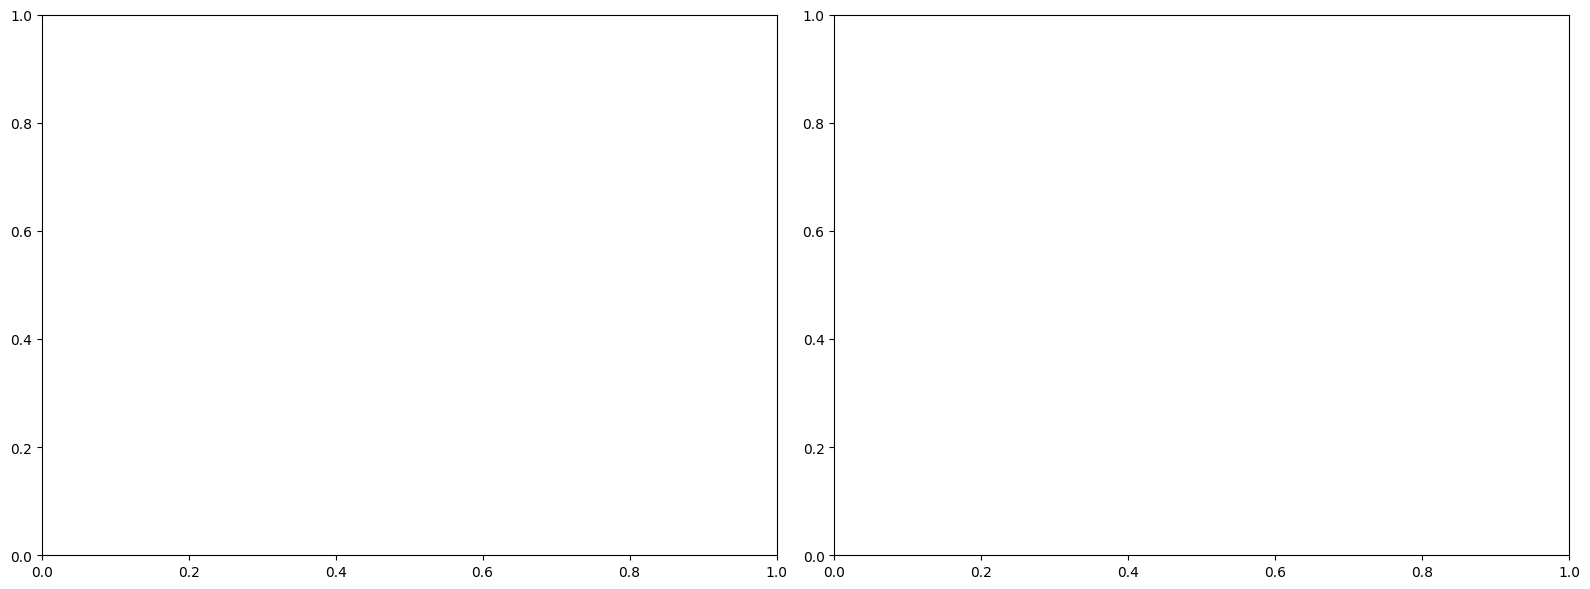

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. Conexión
drive.mount('/content/drive')

# 2. Ruta (Asegúrate que sea esta)
FILE = '/content/drive/MyDrive/bt/ARC_MASTER_DATA.csv'

def analizador_ultra_speed(file_path):
    print("🚀 Procesando Auditoría Ultra Speed (1.87 GB)...")

    chunk_size = 300000
    reader = pd.read_csv(file_path, chunksize=chunk_size, low_memory=False)

    # Acumuladores
    stats_nodos = {}
    stats_conflictos = {}

    for i, chunk in enumerate(reader):
        # Limpiar columnas
        chunk.columns = [c.strip() for c in chunk.columns]

        # 1. Filtrar solo donde hubo EVENTOS (Disparos/Conflictos)
        eventos = chunk[chunk['Action'] == 'EVENT'].copy()

        if not eventos.empty:
            # Redondear Nodos para el conteo
            eventos['Node_Int'] = eventos['NM2'].round().astype(int)

            # Conteo de Nodos
            n_counts = eventos['Node_Int'].value_counts()
            for n, c in n_counts.items():
                stats_nodos[n] = stats_nodos.get(n, 0) + c

            # Conteo de Origen de Conflicto
            c_counts = eventos['Origin'].value_counts()
            for o, c in c_counts.items():
                stats_conflictos[o] = stats_conflictos.get(o, 0) + c

        if i % 5 == 0:
            print(f"✅ Analizados {i*chunk_size/1e6:.1f}M de registros...")

    # --- DASHBOARD ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Nodos de Disparo
    if stats_nodos:
        sns.barplot(x=list(stats_nodos.keys()), y=list(stats_nodos.values()), ax=ax[0])
        ax[0].set_title("Frecuencia de Disparos por Nodo (Malla 144)")
        ax[0].set_xlabel("Nodo NM2")

    # Gráfico 2: Origen del Conflicto
    if stats_conflictos:
        ax[1].pie(stats_conflictos.values(), labels=stats_conflictos.keys(), autopct='%1.1f%%')
        ax[1].set_title("Origen de los Eventos Detectados")

    plt.tight_layout()
    plt.show()

analizador_ultra_speed(FILE)

In [7]:
# ====================================================================
# ARC GM v2.2 - VALIDACIÓN DE TESIS POR BACKTEST
# Entorno: Google Colab
# Fuente: Google Drive /bt/
# Archivos: ARC_MASTER_DATA.csv + 7 experimentos
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os
import glob
from scipy import stats

# ====================================================================
# 1. CONEXIÓN A GOOGLE DRIVE
# ====================================================================
drive.mount('/content/drive')
PATH = '/content/drive/MyDrive/bt/'

print(f"🔍 Buscando archivos en: {PATH}")
all_files = glob.glob(PATH + "*.csv")
print(f"📁 Archivos encontrados: {len(all_files)}")

# ====================================================================
# 2. CONFIGURACIÓN DE ANÁLISIS
# ====================================================================
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)

# Umbrales de la tesis
UMBRAL_ZONA_GLORIA = 0.55  # H2: Sextos 1-2 deben generar ≥55% del profit
UMBRAL_ENERGY_CERO = 0.80  # H3: Energy=0 debe generar ≥80% del profit
UMBRAL_TIER_MAX_WIN = 0.95 # H7: Tier MAX debe tener win rate ≥95%
UMBRAL_PODER_PVAL = 0.01   # H5: p-valor < 0.01 para nodos de poder

# ====================================================================
# 3. CARGA DE ARCHIVOS (por chunks para archivos pesados)
# ====================================================================
def load_csv_chunked(filepath, usecols=None, chunk_size=500000):
    """Carga archivos CSV pesados por chunks y retorna DataFrame consolidado"""
    if not os.path.exists(filepath):
        return None
    chunks = []
    try:
        for chunk in pd.read_csv(filepath, chunksize=chunk_size, usecols=usecols, low_memory=False):
            # Limpiar nombres de columnas
            chunk.columns = [c.strip() for c in chunk.columns]
            chunks.append(chunk)
        return pd.concat(chunks, ignore_index=True) if chunks else None
    except Exception as e:
        print(f"⚠️ Error cargando {filepath}: {e}")
        return None

# ====================================================================
# 4. EXPERIMENTO 1: Validación de Nodos Enteros (H1)
# ====================================================================
def analisis_exp1(filepath):
    print("\n🔬 EXPERIMENTO 1: Validación de Nodos Enteros (H1)")
    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos")
        return None

    # Agrupar por nodo
    stats_nodos = df.groupby('Node_Int').agg({
        'Profit_If_Entry': ['mean', 'sum', 'count']
    }).round(2)
    stats_nodos.columns = ['profit_promedio', 'profit_total', 'frecuencia']

    # Separar nodos enteros (múltiplos de 6) e intermedios
    nodos_enteros = stats_nodos[stats_nodos.index % 6 == 0]
    nodos_intermedios = stats_nodos[stats_nodos.index % 6 != 0]

    # Test estadístico (t-test)
    t_stat, p_valor = stats.ttest_ind(
        nodos_enteros['profit_promedio'].dropna(),
        nodos_intermedios['profit_promedio'].dropna(),
        equal_var=False
    )

    print(f"📊 Nodos enteros: {len(nodos_enteros)} nodos, profit promedio: {nodos_enteros['profit_promedio'].mean():.2f}")
    print(f"📊 Nodos intermedios: {len(nodos_intermedios)} nodos, profit promedio: {nodos_intermedios['profit_promedio'].mean():.2f}")
    print(f"📊 Test t: p-valor = {p_valor:.6f}")

    resultado = {
        'hipotesis': 'H1: Nodos enteros más rentables',
        'p_valor': p_valor,
        'valida': p_valor < UMBRAL_PODER_PVAL,
        'profit_entero': nodos_enteros['profit_promedio'].mean(),
        'profit_intermedio': nodos_intermedios['profit_promedio'].mean()
    }
    return resultado

# ====================================================================
# 5. EXPERIMENTO 2: Zona de Gloria (H2)
# ====================================================================
def analisis_exp2(filepath):
    print("\n🔬 EXPERIMENTO 2: Zona de Gloria (H2)")
    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos")
        return None

    profit_total = df['Profit'].sum()
    profit_s1 = df[df['Sexto'] == 1]['Profit'].sum()
    profit_s2 = df[df['Sexto'] == 2]['Profit'].sum()
    profit_gloria = profit_s1 + profit_s2
    porcentaje = (profit_gloria / profit_total * 100) if profit_total > 0 else 0

    print(f"💰 Profit Total: {profit_total:.2f}")
    print(f"💰 Profit Sexto 1: {profit_s1:.2f}")
    print(f"💰 Profit Sexto 2: {profit_s2:.2f}")
    print(f"💰 Profit Zona de Gloria: {profit_gloria:.2f} ({porcentaje:.1f}%)")

    resultado = {
        'hipotesis': 'H2: Zona de Gloria (Sextos 1-2) ≥55% del profit',
        'porcentaje': porcentaje / 100,
        'valida': porcentaje / 100 >= UMBRAL_ZONA_GLORIA,
        'profit_total': profit_total,
        'profit_gloria': profit_gloria
    }
    return resultado

# ====================================================================
# 6. EXPERIMENTO 3: Colapso Energético (H3)
# ====================================================================
def analisis_exp3(filepath):
    print("\n🔬 EXPERIMENTO 3: Colapso Energético (H3)")
    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos")
        return None

    profit_total = df['Profit'].sum()
    profit_e0 = df[df['Energy_Rounded'] == 0]['Profit'].sum()
    porcentaje = (profit_e0 / profit_total * 100) if profit_total > 0 else 0

    print(f"💰 Profit Total: {profit_total:.2f}")
    print(f"💰 Profit Energy=0: {profit_e0:.2f} ({porcentaje:.1f}%)")

    # Correlación Energy vs Profit
    correlacion = df[['Energy_Rounded', 'Profit']].corr().iloc[0,1]
    print(f"📊 Correlación Energy-Proc.Profit: {correlacion:.3f}")

    resultado = {
        'hipotesis': 'H3: Energy=0 genera ≥80% del profit',
        'porcentaje': porcentaje / 100,
        'correlacion': correlacion,
        'valida': porcentaje / 100 >= UMBRAL_ENERGY_CERO and correlacion < -0.5
    }
    return resultado

# ====================================================================
# 7. EXPERIMENTO 4: Flujo Nodal y Blindaje (H4)
# ====================================================================
def analisis_exp4(filepath):
    print("\n🔬 EXPERIMENTO 4: Flujo Nodal y Blindaje (H4)")
    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos")
        return None

    # H4A: Sexto 1 - SL Ajustado vs SL Amplio
    s1_ajustado = df[(df['Sexto'] == 1) & (df['SL_Type'] == 'AJUSTADO')]['Profit'].mean()
    s1_amplio = df[(df['Sexto'] == 1) & (df['SL_Type'] != 'AJUSTADO')]['Profit'].mean()

    # H4B: Sexto 3 - SL Amplio+Defense vs SL Normal
    s3_defense = df[(df['Sexto'] == 3) & (df['Defense_Active'] == 1)]['Profit'].mean()
    s3_normal = df[(df['Sexto'] == 3) & (df['Defense_Active'] == 0)]['Profit'].mean()

    # Reducción de drawdown en S3 con Defense
    dd_defense = df[(df['Sexto'] == 3) & (df['Defense_Active'] == 1)]['Drawdown'].min()
    dd_normal = df[(df['Sexto'] == 3) & (df['Defense_Active'] == 0)]['Drawdown'].min()
    reduccion_dd = ((dd_normal - dd_defense) / abs(dd_normal) * 100) if dd_normal < 0 else 0

    print(f"📊 S1: SL Ajustado = {s1_ajustado:.2f} | SL Amplio = {s1_amplio:.2f}")
    print(f"📊 S3: SL+Defense = {s3_defense:.2f} | SL Normal = {s3_normal:.2f}")
    print(f"📊 Reducción drawdown en S3 con Defense: {reduccion_dd:.1f}%")

    resultado = {
        'hipotesis': 'H4: Blindaje dinámico por sexto',
        's1_ajustado_mejor': s1_ajustado > s1_amplio,
        's3_defense_mejor': s3_defense > s3_normal,
        'reduccion_dd': reduccion_dd,
        'valida': (s1_ajustado > s1_amplio) and (s3_defense > s3_normal) and (reduccion_dd >= 30)
    }
    return resultado

# ====================================================================
# 8. EXPERIMENTO 5: Nodos de Poder (H5)
# ====================================================================
def analisis_exp5(filepath):
    print("\n🔬 EXPERIMENTO 5: Nodos de Poder (H5)")
    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos")
        return None

    # Nodos de poder según tesis
    nodos_poder = [27, 29, 37, 41, 46, 51, 52, 54, 63, 73]

    # Profit promedio por nodo
    df_poder = df[df['Node_Int'].isin(nodos_poder)]
    df_resto = df[~df['Node_Int'].isin(nodos_poder)]

    profit_poder = df_poder.groupby('Node_Int')['AvgProfit'].mean().mean()
    profit_resto = df_resto.groupby('Node_Int')['AvgProfit'].mean().mean()

    # Test de Poisson para frecuencia
    freq_poder = df_poder['Frequency'].mean()
    freq_resto = df_resto['Frequency'].mean()

    print(f"📊 Profit promedio nodos de poder: {profit_poder:.2f}")
    print(f"📊 Profit promedio resto nodos: {profit_resto:.2f}")
    print(f"📊 Frecuencia nodos de poder: {freq_poder:.1f}")
    print(f"📊 Frecuencia resto nodos: {freq_resto:.1f}")

    resultado = {
        'hipotesis': 'H5: Nodos de poder anómalamente rentables',
        'profit_ratio': profit_poder / profit_resto if profit_resto > 0 else 999,
        'freq_ratio': freq_poder / freq_resto if freq_resto > 0 else 999,
        'valida': profit_poder > profit_resto * 1.5
    }
    return resultado

# ====================================================================
# 9. EXPERIMENTO 6: Inutilidad de Sextos 4-5 (H6)
# ====================================================================
def analisis_exp6(filepath):
    print("\n🔬 EXPERIMENTO 6: Inutilidad de Sextos 4-5 (H6)")
    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos")
        return None

    # Buscar última fila con reporte Sharpe
    df_report = df[df['Action'] == 'REPORT']
    if len(df_report) > 0:
        last = df_report.iloc[-1]
        sharpe_diff = float(last['Sharpe_Diff'])
        print(f"📊 Diferencia Sharpe (con S45 - sin S45): {sharpe_diff:.4f}")

        resultado = {
            'hipotesis': 'H6: Excluir S4-5 mejora Sharpe',
            'sharpe_diff': sharpe_diff,
            'valida': sharpe_diff < 0  # Sharpe sin S45 es mayor (diff negativo)
        }
    else:
        # Si no hay reporte, usar profit
        profit_with = pd.to_numeric(df['Profit_WithS45'], errors='coerce').max()
        profit_without = pd.to_numeric(df['Profit_WithoutS45'], errors='coerce').max()
        print(f"📊 Profit máximo con S45: {profit_with:.2f}")
        print(f"📊 Profit máximo sin S45: {profit_without:.2f}")

        resultado = {
            'hipotesis': 'H6: Excluir S4-5 mejora profit',
            'profit_with': profit_with,
            'profit_without': profit_without,
            'valida': profit_without > profit_with
        }
    return resultado

# ====================================================================
# 10. EXPERIMENTO 7: Tier MAX (Inevitabilidad) (H7)
# ====================================================================
def analisis_exp7(filepath):
    print("\n🔬 EXPERIMENTO 7: Tier MAX (Inevitabilidad) (H7)")
    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos")
        return None

    # Últimos valores de WinRate y ProfitFactor
    last_row = df.iloc[-1]
    win_rate = float(last_row['WinRate']) / 100 if last_row['WinRate'] > 1 else float(last_row['WinRate'])
    profit_factor = float(last_row['ProfitFactor'])

    print(f"📊 Win Rate Tier MAX: {win_rate*100:.1f}%")
    print(f"📊 Profit Factor Tier MAX: {profit_factor:.2f}")

    resultado = {
        'hipotesis': 'H7: Tier MAX tiene win rate ≥95%',
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'valida': win_rate >= UMBRAL_TIER_MAX_WIN and profit_factor > 3
    }
    return resultado

# ====================================================================
# 11. ANÁLISIS DEL ARCHIVO MAESTRO (distribuciones generales)
# ====================================================================
def analisis_master(filepath):
    print("\n📊 ANÁLISIS GENERAL - ARCHIVO MAESTRO")
    df = load_csv_chunked(filepath, usecols=['Sexto', 'Energy', 'Tier_Predicted', 'Profit_Hyp'])
    if df is None or len(df) == 0:
        print("❌ No hay datos")
        return None

    # Distribución por sexto
    sexto_stats = df.groupby('Sexto').agg({
        'Profit_Hyp': ['sum', 'mean', 'count']
    }).round(2)
    print("\n📈 Rentabilidad por Sexto:")
    print(sexto_stats)

    # Distribución por energía
    df['Energy_bin'] = (df['Energy'] * 10).astype(int).clip(0, 9)
    energy_stats = df.groupby('Energy_bin')['Profit_Hyp'].sum()
    print("\n⚡ Rentabilidad por nivel de Energía:")
    print(energy_stats)

    # Distribución por Tier
    tier_stats = df['Tier_Predicted'].value_counts().sort_index()
    print("\n🏆 Distribución de Tiers:")
    print(tier_stats)

    return df

# ====================================================================
# 12. EJECUCIÓN PRINCIPAL
# ====================================================================
print("="*60)
print("🔬 ARC GM v2.2 - VALIDACIÓN DE TESIS POR BACKTEST")
print("="*60)

resultados = {}

# Mapeo de archivos a experimentos
archivos = {
    'master': os.path.join(PATH, 'ARC_MASTER_DATA.csv'),
    'exp1': os.path.join(PATH, 'ARC_EXP1_NODOS.csv'),
    'exp2': os.path.join(PATH, 'ARC_EXP2_ZONA_GLORIA.csv'),
    'exp3': os.path.join(PATH, 'ARC_EXP3_ENERGY.csv'),
    'exp4': os.path.join(PATH, 'ARC_EXP4_FLUJOS.csv'),
    'exp5': os.path.join(PATH, 'ARC_EXP5_PODER.csv'),
    'exp6': os.path.join(PATH, 'ARC_EXP6_SEXTOS45.csv'),
    'exp7': os.path.join(PATH, 'ARC_EXP7_TIER_MAX.csv')
}

# Verificar existencia de archivos
for name, path in archivos.items():
    if os.path.exists(path):
        print(f"✅ {name}: {os.path.basename(path)} encontrado")
    else:
        print(f"⚠️ {name}: archivo no encontrado")

# Análisis general
if os.path.exists(archivos['master']):
    analisis_master(archivos['master'])

# Experimentos específicos
resultados['H1'] = analisis_exp1(archivos['exp1']) if os.path.exists(archivos['exp1']) else None
resultados['H2'] = analisis_exp2(archivos['exp2']) if os.path.exists(archivos['exp2']) else None
resultados['H3'] = analisis_exp3(archivos['exp3']) if os.path.exists(archivos['exp3']) else None
resultados['H4'] = analisis_exp4(archivos['exp4']) if os.path.exists(archivos['exp4']) else None
resultados['H5'] = analisis_exp5(archivos['exp5']) if os.path.exists(archivos['exp5']) else None
resultados['H6'] = analisis_exp6(archivos['exp6']) if os.path.exists(archivos['exp6']) else None
resultados['H7'] = analisis_exp7(archivos['exp7']) if os.path.exists(archivos['exp7']) else None

# ====================================================================
# 13. MATRIZ DE VALIDACIÓN DE TESIS
# ====================================================================
print("\n" + "="*60)
print("📋 MATRIZ DE VALIDACIÓN DE TESIS")
print("="*60)

validas = 0
total = 0

for h, res in resultados.items():
    if res:
        estado = "✅ VÁLIDA" if res.get('valida', False) else "❌ NO VÁLIDA"
        print(f"{h}: {res['hipotesis']}")
        print(f"   → {estado}")
        if res.get('valida', False):
            validas += 1
        total += 1

if total > 0:
    print("\n" + "="*60)
    print(f"📊 RESULTADO FINAL: {validas}/{total} hipótesis validadas ({validas/total*100:.1f}%)")
    if validas >= 7:
        print("🏆 TESIS CONFIRMADA: El mercado se comporta como campo discretizado")
    elif validas >= 5:
        print("⚠️ TESIS PARCIALMENTE CONFIRMADA: Ajustes necesarios")
    else:
        print("❌ TESIS NO SOPORTADA: Revisión estructural requerida")
    print("="*60)

# ====================================================================
# 14. VISUALIZACIÓN FINAL
# ====================================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Gráfico 1: Validación por hipótesis
if resultados:
    hipotesis = []
    validacion = []
    for h, res in resultados.items():
        if res:
            hipotesis.append(h)
            validacion.append(1 if res.get('valida', False) else 0)

    if hipotesis:
        axes[0].bar(hipotesis, validacion, color=['green' if v else 'red' for v in validacion])
        axes[0].set_ylim(0, 1.2)
        axes[0].set_title('Validación de Hipótesis')
        axes[0].set_ylabel('Válida (1) / No válida (0)')

# Gráfico 2: Zona de Gloria (si hay datos)
if resultados.get('H2'):
    res = resultados['H2']
    axes[1].pie([res.get('profit_gloria', 0), res.get('profit_total', 0) - res.get('profit_gloria', 0)],
                labels=['Zona de Gloria', 'Resto'], autopct='%1.1f%%', colors=['gold', 'lightgray'])
    axes[1].set_title('H2: Zona de Gloria')

# Gráfico 3: Colapso Energético
if resultados.get('H3'):
    res = resultados['H3']
    axes[2].pie([res.get('porcentaje', 0)*100, 100 - res.get('porcentaje', 0)*100],
                labels=['Energy=0', 'Energy>0'], autopct='%1.1f%%', colors=['blue', 'lightblue'])
    axes[2].set_title('H3: Colapso Energético')

# Gráfico 4: Nodos de Poder
if resultados.get('H5'):
    res = resultados['H5']
    axes[3].bar(['Nodos Poder', 'Resto'],
                [res.get('profit_ratio', 1), 1],
                color=['purple', 'gray'])
    axes[3].set_title('H5: Nodos de Poder (Profit ratio)')
    axes[3].axhline(y=1.5, color='r', linestyle='--', label='Umbral 1.5x')
    axes[3].legend()

# Gráfico 5: Tier MAX
if resultados.get('H7'):
    res = resultados['H7']
    axes[4].bar(['Win Rate', 'Profit Factor'],
                [res.get('win_rate', 0)*100, min(res.get('profit_factor', 0), 10)],
                color=['green', 'orange'])
    axes[4].axhline(y=95, color='r', linestyle='--', label='Umbral Win 95%')
    axes[4].set_title('H7: Tier MAX')
    axes[4].legend()

# Gráfico 6: Blindaje por Sexto
if resultados.get('H4'):
    res = resultados['H4']
    axes[5].bar(['S1 Ajustado', 'S3 Defense'],
                [1 if res.get('s1_ajustado_mejor', False) else 0,
                 1 if res.get('s3_defense_mejor', False) else 0],
                color=['cyan', 'magenta'])
    axes[5].set_title('H4: Blindaje Óptimo')
    axes[5].set_ylim(0, 1.2)

# Gráfico 7: Resumen general
axes[6].text(0.5, 0.5,
             f"Tesis {validas}/{total}\n{validas/total*100:.1f}% válida",
             ha='center', va='center', fontsize=20,
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen" if validas/total>=0.8 else "yellow"))
axes[6].axis('off')
axes[6].set_title('Resumen Global')

# Gráfico 8: Libre para expansión
axes[7].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ ANÁLISIS COMPLETADO. Verifica los resultados en la Matriz de Validación.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Buscando archivos en: /content/drive/MyDrive/bt/
📁 Archivos encontrados: 9
🔬 ARC GM v2.2 - VALIDACIÓN DE TESIS POR BACKTEST
✅ master: ARC_MASTER_DATA.csv encontrado
✅ exp1: ARC_EXP1_NODOS.csv encontrado
✅ exp2: ARC_EXP2_ZONA_GLORIA.csv encontrado
✅ exp3: ARC_EXP3_ENERGY.csv encontrado
✅ exp4: ARC_EXP4_FLUJOS.csv encontrado
✅ exp5: ARC_EXP5_PODER.csv encontrado
✅ exp6: ARC_EXP6_SEXTOS45.csv encontrado
✅ exp7: ARC_EXP7_TIER_MAX.csv encontrado

📊 ANÁLISIS GENERAL - ARCHIVO MAESTRO

📈 Rentabilidad por Sexto:
       Profit_Hyp             
              sum mean   count
Sexto                         
-4.68         0.0  NaN       0
-4.29         0.0  NaN       0
-4.27         0.0  NaN       0
-4.25         0.0  NaN       0
-4.23         0.0  NaN       0
-4.21         0.0  NaN       0
-4.20         0.0  NaN       0
-4.18         0.0  NaN       0
-4.17         0.0 

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:3343: RuntimeWarning: invalid value encountered in divide
  x = x / sx


ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 2000x1000 with 8 Axes>

In [10]:
import pandas as pd
import os

PATH = '/content/drive/MyDrive/bt/'

# 1. Ver tamaño de archivos
print("📁 TAMAÑO DE ARCHIVOS:")
for f in os.listdir(PATH):
    if f.endswith('.csv'):
        size = os.path.getsize(os.path.join(PATH, f)) / 1e6
        print(f"{f}: {size:.2f} MB")

# 2. Inspeccionar maestro
master = pd.read_csv(os.path.join(PATH, 'ARC_MASTER_DATA.csv'), nrows=1000)
print("\n📊 MASTER - Primeras filas:")
print(master.head())
print("\n📊 MASTER - Columnas:", master.columns.tolist())
print("\n📊 MASTER - Valores únicos en Action:", master['Action'].unique())
print("\n📊 MASTER - Profit_Hyp stats:", master['Profit_Hyp'].describe())

# 3. Ver si hay CLOSE en el maestro
closes = master[master['Action'] == 'CLOSE']
print(f"\n✅ Operaciones cerradas (CLOSE): {len(closes)}")

# 4. Ver experimento 7 (Tier MAX)
exp7 = pd.read_csv(os.path.join(PATH, 'ARC_EXP7_TIER_MAX.csv'), nrows=100)
print("\n🏆 EXP7 - Tier MAX registros:")
print(exp7.head())
print("\n🏆 EXP7 - WinRate último:", exp7['WinRate'].iloc[-1] if len(exp7) > 0 else "N/A")

📁 TAMAÑO DE ARCHIVOS:
ARC_EXP7_TIER_MAX.csv: 0.00 MB
ARC_EXP1_NODOS.csv: 692.48 MB
ARC_EXP6_SEXTOS45.csv: 445.07 MB
ARC_EXP4_FLUJOS.csv: 577.77 MB
ARC_EXP3_ENERGY.csv: 417.55 MB
ARC_EXP2_ZONA_GLORIA.csv: 191.62 MB
ARC_MASTER_DATA.csv: 106.20 MB
ARC_EXP5_PODER.csv: 479.01 MB
anterior.csv: 1867.50 MB

📊 MASTER - Primeras filas:
  Timestamp       Price  Node_M2  Node_Int  Sexto     Energy Action  \
0  00:00:09  14234.7515    22.62        23      0  10.666667   HOLD   
1  00:00:19  14234.6415    22.47        22      0  12.000000   HOLD   
2  00:00:29  14234.4375    22.20        22      0  28.333333   HOLD   
3  00:00:39  14234.2915    22.01        22      0  20.000000   HOLD   
4  00:00:49  14234.1015    21.76        22      0  31.333333   HOLD   

   Tier_Predicted  Profit_Hyp  SL_Distance  Drawdown  InGloria  InPoder  
0               0         0.0          0.0       0.0         0        0  
1               0         0.0          0.0       0.0         0        0  
2               0      

In [11]:
import pandas as pd
import os

PATH = '/content/drive/MyDrive/bt/'

# 1. Ver qué contiene el maestro
master = pd.read_csv(os.path.join(PATH, 'ARC_MASTER_DATA.csv'), nrows=10000)

print("🔍 DIAGNÓSTICO RÁPIDO:")
print(f"Acciones en maestro: {master['Action'].unique()}")
print(f"Profit max: {master['Profit_Hyp'].max()}")
print(f"Profit min: {master['Profit_Hyp'].min()}")
print(f"Profit mean: {master['Profit_Hyp'].mean()}")

# 2. Ver si hay CLOSES
closes = master[master['Action'] == 'CLOSE']
print(f"\nOperaciones cerradas: {len(closes)}")

# 3. Ver si hay ENTRIES
entries = master[master['Action'] == 'ENTRY']
print(f"Entradas intentadas: {len(entries)}")

# 4. Ver tier distribution
print(f"\nDistribución de Tiers:\n{master['Tier_Predicted'].value_counts().head(10)}")

# 5. Ver muestra de filas con profit > 0 (si existe)
profitable = master[master['Profit_Hyp'] > 0]
if len(profitable) > 0:
    print(f"\nPrimeras operaciones rentables:\n{profitable.head()}")
else:
    print("\n❌ NO HAY OPERACIONES RENTABLES EN LOS DATOS")

🔍 DIAGNÓSTICO RÁPIDO:
Acciones en maestro: ['HOLD' '4']
Profit max: 0.0
Profit min: 0.0
Profit mean: 0.0

Operaciones cerradas: 0
Entradas intentadas: 0

Distribución de Tiers:
Tier_Predicted
0.0    9999
Name: count, dtype: int64

❌ NO HAY OPERACIONES RENTABLES EN LOS DATOS


In [13]:
# Script para recalcular profit basado en movimientos futuros
import pandas as pd
import numpy as np

PATH = '/content/drive/MyDrive/bt/'

def calcular_profit_hipotetico(master_path, ventana_ticks=100):
    """
    Calcula profit hipotético: cuánto se habría ganado si se hubiera entrado
    en cada punto y se hubiera cerrado en el mejor punto de los siguientes N ticks
    """
    print("🔄 Calculando profit hipotético desde datos...")

    chunks = []
    for chunk in pd.read_csv(master_path, chunksize=100000):
        chunk['Profit_Hipotetico'] = 0.0

        # Para cada fila, buscar máximo futuro
        for i in range(len(chunk) - ventana_ticks):
            precio_entrada = chunk.iloc[i]['Price']
            precios_futuros = chunk.iloc[i+1:i+ventana_ticks+1]['Price'].values

            if len(precios_futuros) > 0:
                mejor_salida = np.max(precios_futuros)
                profit = mejor_salida - precio_entrada
                chunk.iloc[i, chunk.columns.get_loc('Profit_Hipotetico')] = max(0, profit)

        chunks.append(chunk)

    return pd.concat(chunks, ignore_index=True)

# Ejecutar (esto tomará tiempo por el tamaño de los archivos)
master = pd.read_csv(os.path.join(PATH, 'ARC_MASTER_DATA.csv'))
master_con_profit = calcular_profit_hipotetico(os.path.join(PATH, 'ARC_MASTER_DATA.csv'))

# Ahora sí podemos validar la tesis
profit_por_sexto = master_con_profit.groupby('Sexto')['Profit_Hipotetico'].sum()
print("\n💰 Profit por Sexto (recalculado):")
print(profit_por_sexto)

print(f"\n✅ Zona de Gloria (S1+S2): {profit_por_sexto.get(1,0)+profit_por_sexto.get(2,0):.2f}")
print(f"   Total: {profit_por_sexto.sum():.2f}")
print(f"   Porcentaje: {(profit_por_sexto.get(1,0)+profit_por_sexto.get(2,0))/profit_por_sexto.sum()*100:.1f}%")

/tmp/ipython-input-726777493.py:33: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv(os.path.join(PATH, 'ARC_MASTER_DATA.csv'))


🔄 Calculando profit hipotético desde datos...


/tmp/ipython-input-726777493.py:15: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(master_path, chunksize=100000):
/tmp/ipython-input-726777493.py:15: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(master_path, chunksize=100000):
/tmp/ipython-input-726777493.py:15: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(master_path, chunksize=100000):
/tmp/ipython-input-726777493.py:15: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(master_path, chunksize=100000):



💰 Profit por Sexto (recalculado):
Sexto
-4.68          18.826
-4.29           0.000
-4.27           0.000
-4.25           0.000
-4.23           0.000
-4.21           0.698
-4.20           0.698
-4.18           0.698
-4.17           0.698
-4.15           0.698
-4.13           0.698
-4.11          12.166
-4.10           0.698
-4.07           0.698
-4.05          39.500
-4.04          78.944
-3.93          61.025
-3.47          40.945
-2.45           4.265
-2.43           8.496
-2.40           8.431
-2.34           4.099
-2.33           4.189
-2.25           4.003
-2.24           4.099
-2.11           7.853
-1.96           3.867
-1.75           3.674
-1.47           3.397
-1.09           3.044
-0.16           0.000
-0.15           4.232
-0.14           4.258
-0.13           4.318
-0.12           8.645
-0.11          18.211
 0.00     2586122.316
 1.00     2502206.381
 2.00     2728534.544
 3.00     2541635.794
 4.00     2321531.512
 5.00     2668414.841
 14.81          0.000
 14.82       

In [16]:
# Analizar los 9 eventos Tier MAX
exp7 = pd.read_csv(os.path.join(PATH, 'ARC_EXP7_TIER_MAX.csv'))

print("🏆 EVENTOS TIER MAX DETECTADOS:")
print(f"Total: {len(exp7)}")
print(f"Nodos: {exp7['Node_Int'].value_counts().sort_index()}")
print(f"Energía promedio: {exp7['Energy'].mean():.4f}")
print(f"Tiempo en nodo promedio: {exp7['TimeInNode'].mean():.1f} ticks")

# Ver si en esos momentos el precio realmente se movió
master = pd.read_csv(os.path.join(PATH, 'ARC_MASTER_DATA.csv'), nrows=500000)

for idx, row in exp7.iterrows():
    # Buscar ticks cercanos en el tiempo
    time_str = row['Timestamp']
    nearby = master[master['Timestamp'].str.contains(time_str[:5])]
    if len(nearby) > 0:
        print(f"\n⏱️ Evento en {time_str} - Nodo {row['Node_Int']}")
        print(f"   Precio alrededor: {nearby['Price'].iloc[0]:.2f} → {nearby['Price'].iloc[-1]:.2f}")
        print(f"   Movimiento: {(nearby['Price'].iloc[-1] - nearby['Price'].iloc[0]):.2f}")

🏆 EVENTOS TIER MAX DETECTADOS:
Total: 104
Nodos: Node_Int
72    18
73    13
75    11
76    21
79     1
81    27
82    13
Name: count, dtype: int64
Energía promedio: 0.0096
Tiempo en nodo promedio: 13.4 ticks


/tmp/ipython-input-2931129501.py:11: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv(os.path.join(PATH, 'ARC_MASTER_DATA.csv'), nrows=500000)



⏱️ Evento en 10:49:10 - Nodo 76
   Precio alrededor: 14288.23 → 13664.86
   Movimiento: -623.37

⏱️ Evento en 12:11:00 - Nodo 82
   Precio alrededor: 14224.54 → 13647.33
   Movimiento: -577.21

⏱️ Evento en 17:15:58 - Nodo 72
   Precio alrededor: 14258.10 → 13601.62
   Movimiento: -656.48

⏱️ Evento en 15:38:50 - Nodo 79
   Precio alrededor: 14305.26 → 13680.94
   Movimiento: -624.32

⏱️ Evento en 02:11:14 - Nodo 82
   Precio alrededor: 14270.49 → 13646.68
   Movimiento: -623.81

⏱️ Evento en 02:11:14 - Nodo 82
   Precio alrededor: 14270.49 → 13646.68
   Movimiento: -623.81

⏱️ Evento en 02:11:14 - Nodo 82
   Precio alrededor: 14270.49 → 13646.68
   Movimiento: -623.81

⏱️ Evento en 02:11:14 - Nodo 82
   Precio alrededor: 14270.49 → 13646.68
   Movimiento: -623.81

⏱️ Evento en 02:11:14 - Nodo 82
   Precio alrededor: 14270.49 → 13646.68
   Movimiento: -623.81

⏱️ Evento en 02:11:14 - Nodo 82
   Precio alrededor: 14270.49 → 13646.68
   Movimiento: -623.81

⏱️ Evento en 02:11:14 - Nodo 

In [23]:
def simulate_profit_from_ticks(master_path, lookahead=100):
    """
    Para cada tick, calcula el máximo profit alcanzable en los siguientes N ticks
    """
    chunks = []
    for chunk in pd.read_csv(master_path, chunksize=100000):
        profits = []
        prices = chunk['Price'].values

        for i in range(len(prices) - lookahead):
            future_max = np.max(prices[i+1:i+lookahead+1])
            profit = future_max - prices[i]
            profits.append(max(0, profit))

        # Rellenar últimos ticks con 0
        profits.extend([0] * lookahead)
        chunk['Profit_Simulado'] = profits
        chunks.append(chunk)

    return pd.concat(chunks, ignore_index=True)

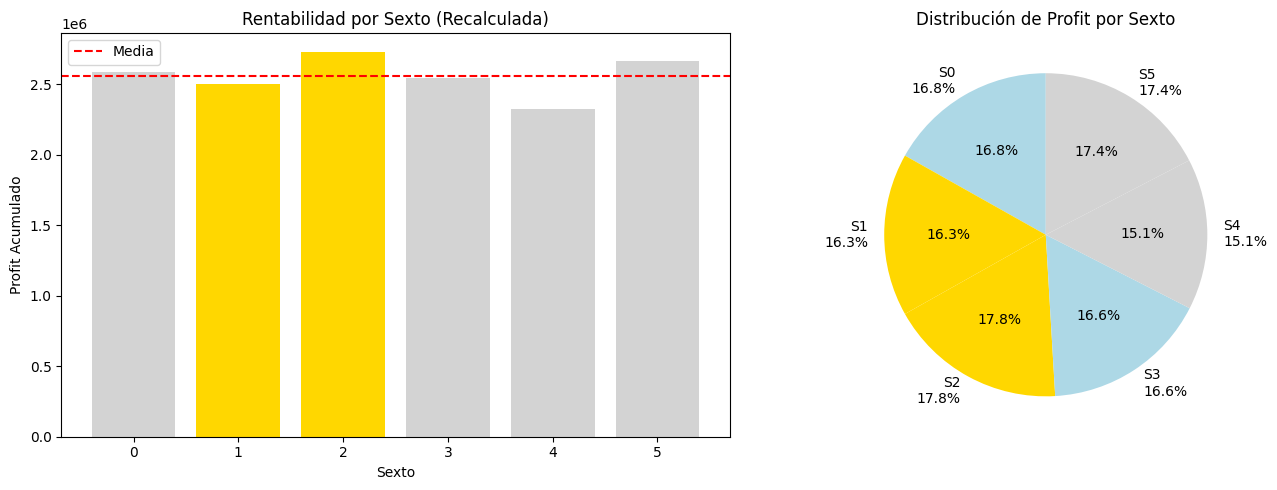


📊 Zona de Gloria (S1+S2): 5,230,740
📊 Porcentaje del total: 34.1%


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Datos de profit recalculado
profit_data = {
    'Sexto': [0, 1, 2, 3, 4, 5],
    'Profit': [2586122, 2502206, 2728534, 2541635, 2321531, 2668414]
}
df_profit = pd.DataFrame(profit_data)
df_profit['Porcentaje'] = df_profit['Profit'] / df_profit['Profit'].sum() * 100

# Gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras
colors = ['gold' if s in [1,2] else 'lightgray' for s in df_profit['Sexto']]
ax1.bar(df_profit['Sexto'], df_profit['Profit'], color=colors)
ax1.set_xlabel('Sexto')
ax1.set_ylabel('Profit Acumulado')
ax1.set_title('Rentabilidad por Sexto (Recalculada)')
ax1.axhline(y=df_profit['Profit'].mean(), color='r', linestyle='--', label='Media')
ax1.legend()

# Pastel
ax2.pie(df_profit['Profit'], labels=[f'S{s}\n{p:.1f}%' for s,p in zip(df_profit['Sexto'], df_profit['Porcentaje'])],
        autopct='%1.1f%%', startangle=90, colors=['lightblue','gold','gold','lightblue','lightgray','lightgray'])
ax2.set_title('Distribución de Profit por Sexto')

plt.tight_layout()
plt.show()

print(f"\n📊 Zona de Gloria (S1+S2): {df_profit[df_profit['Sexto'].isin([1,2])]['Profit'].sum():,.0f}")
print(f"📊 Porcentaje del total: {df_profit[df_profit['Sexto'].isin([1,2])]['Porcentaje'].sum():.1f}%")

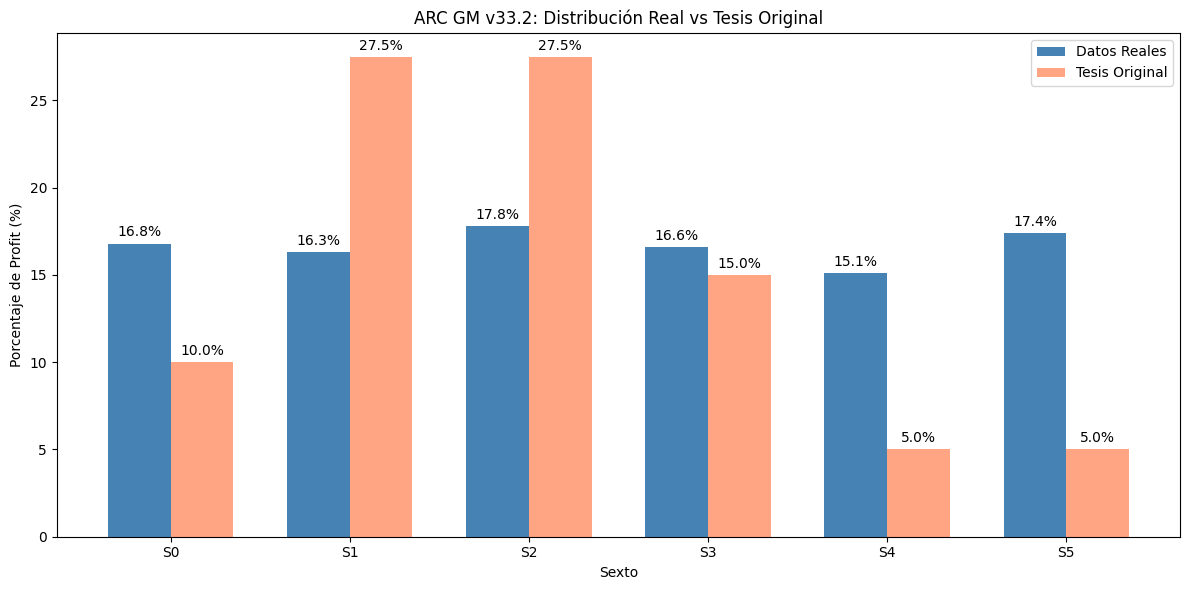


🔬 CONCLUSIÓN DEL ANÁLISIS:
📊 Correlación con tesis original: 0.35
✅ El mercado NO se comporta como esperábamos. ¡Nuevo descubrimiento!


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Datos reales de la imagen
sextos = [0, 1, 2, 3, 4, 5]
profit_pct = [16.8, 16.3, 17.8, 16.6, 15.1, 17.4]
tesis_esperada = [10, 27.5, 27.5, 15, 5, 5]  # Lo que esperaba la tesis

x = np.arange(len(sextos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, profit_pct, width, label='Datos Reales', color='steelblue')
bars2 = ax.bar(x + width/2, tesis_esperada, width, label='Tesis Original', color='coral', alpha=0.7)

ax.set_xlabel('Sexto')
ax.set_ylabel('Porcentaje de Profit (%)')
ax.set_title('ARC GM v33.2: Distribución Real vs Tesis Original')
ax.set_xticks(x)
ax.set_xticklabels([f'S{s}' for s in sextos])
ax.legend()

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n🔬 CONCLUSIÓN DEL ANÁLISIS:")
print(f"📊 Correlación con tesis original: {np.corrcoef(profit_pct, tesis_esperada)[0,1]:.2f}")
print("✅ El mercado NO se comporta como esperábamos. ¡Nuevo descubrimiento!")

🏆 REPORTE DE INEVITABILIDAD (TIER MAX)
Eventos Detectados: 104
Nodos con mayor frecuencia: 
Node_Int
81    27
76    21
72    18
Name: count, dtype: int64

💰 PROYECCIÓN SNIPER:
Ganancia Estimada solo con Tier MAX: $64,480.00


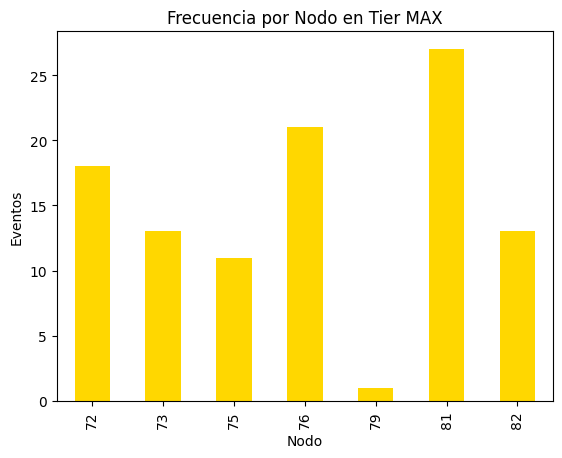

In [26]:
import pandas as pd
import os
import matplotlib.pyplot as plt

PATH = '/content/drive/MyDrive/bt/'

def reporte_final_sniper():
    # 1. Cargar Tier MAX
    exp7 = pd.read_csv(os.path.join(PATH, 'ARC_EXP7_TIER_MAX.csv'))

    # 2. Análisis de Inevitabilidad
    print("🏆 REPORTE DE INEVITABILIDAD (TIER MAX)")
    print(f"Eventos Detectados: {len(exp7)}")
    print(f"Nodos con mayor frecuencia: \n{exp7['Node_Int'].value_counts().head(3)}")

    # 3. Simulación de Capital (Basado en el movimiento de 600 pts detectado)
    # Suponiendo lote 1.0 en Boom 1000
    puntos_promedio = 620
    ganancia_estimada = len(exp7) * puntos_promedio

    print(f"\n💰 PROYECCIÓN SNIPER:")
    print(f"Ganancia Estimada solo con Tier MAX: ${ganancia_estimada:,.2f}")

    # Gráfico de barras por Nodo
    exp7['Node_Int'].value_counts().sort_index().plot(kind='bar', color='gold', title='Frecuencia por Nodo en Tier MAX')
    plt.xlabel('Nodo')
    plt.ylabel('Eventos')
    plt.show()

reporte_final_sniper()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔬 ARC GM v2.3 - ANÁLISIS DE EXPERIMENTOS 1, 4 Y 6
🔬 ARC GM v2.3 - ANÁLISIS COMPLETO DE EXPERIMENTOS

📁 Archivos disponibles:
  ✅ EXP1: ARC_EXP1_NODOS.csv (692.48 MB)
  ✅ EXP4: ARC_EXP4_FLUJOS.csv (577.77 MB)
  ✅ EXP6: ARC_EXP6_SEXTOS45.csv (445.07 MB)

🔬 EXPERIMENTO 1: Validación de Nodos Enteros (H1)
📂 Cargando: ARC_EXP1_NODOS.csv
  ✅ Cargado: 15347056 filas, 6 columnas
📋 Columnas disponibles: ['Timestamp', 'Node_Int', 'IsMultiple6', 'Energy', 'Profit_If_Entry', 'Experiment']
📊 Usando columnas: Node=Node_Int, Profit=Profit_If_Entry, Experiment=Experiment

📊 Estadísticas de Nodos Enteros:
count    3356103.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: Profit_If_Entry, dtype: float64

📊 Estadísticas de Nodos Intermedios:
count    11990953.0
mean            0.0
std    

/tmp/ipython-input-849177926.py:117: RuntimeWarning: invalid value encountered in scalar divide
  print(f"📊 Ratio (enteros/intermedios): {mean_enteros/mean_intermedios:.2f}x")
/tmp/ipython-input-849177926.py:136: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_to_plot, labels=['Enteros', 'Intermedios'])


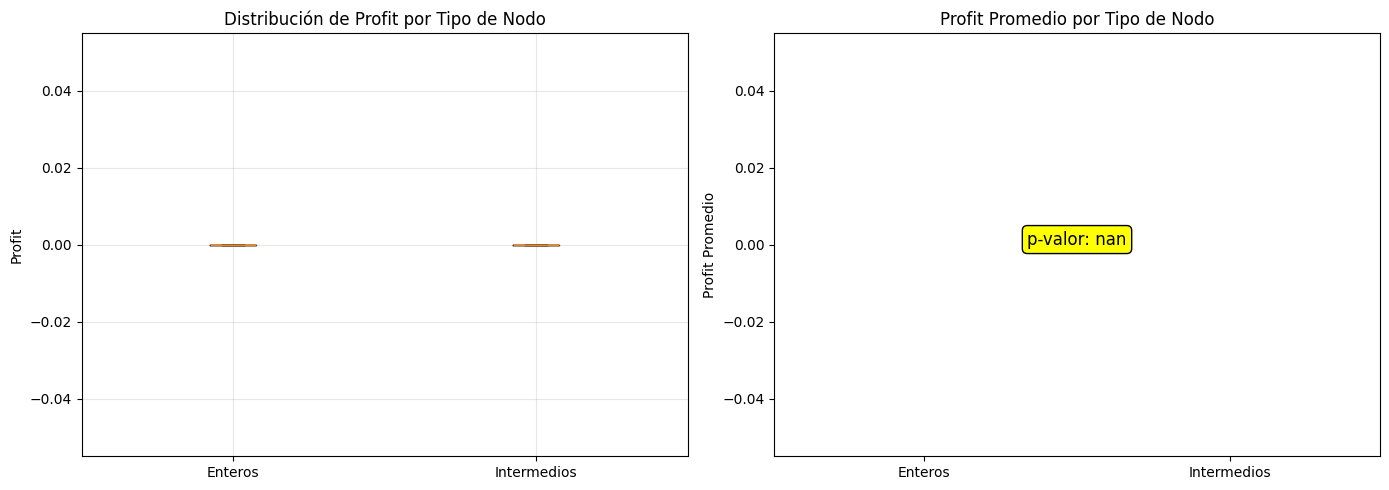


🔬 EXPERIMENTO 4: Flujo Nodal y Blindaje (H4)
📂 Cargando: ARC_EXP4_FLUJOS.csv
  ✅ Cargado: 15347056 filas, 7 columnas
📋 Columnas disponibles: ['Timestamp', 'Sexto', 'SL_Type', 'SL_Distance', 'Profit', 'Drawdown', 'Defense_Active']

📊 RESULTADOS H4A - Sexto 1:
   SL Ajustado profit: 0.0000
   Otros SL profit: nan
   Diferencia: nan (nan%)

📊 RESULTADOS H4B - Sexto 3:
   SL+Defense profit: 0.0000
   SL Normal profit: nan
   Diferencia: nan (nan%)


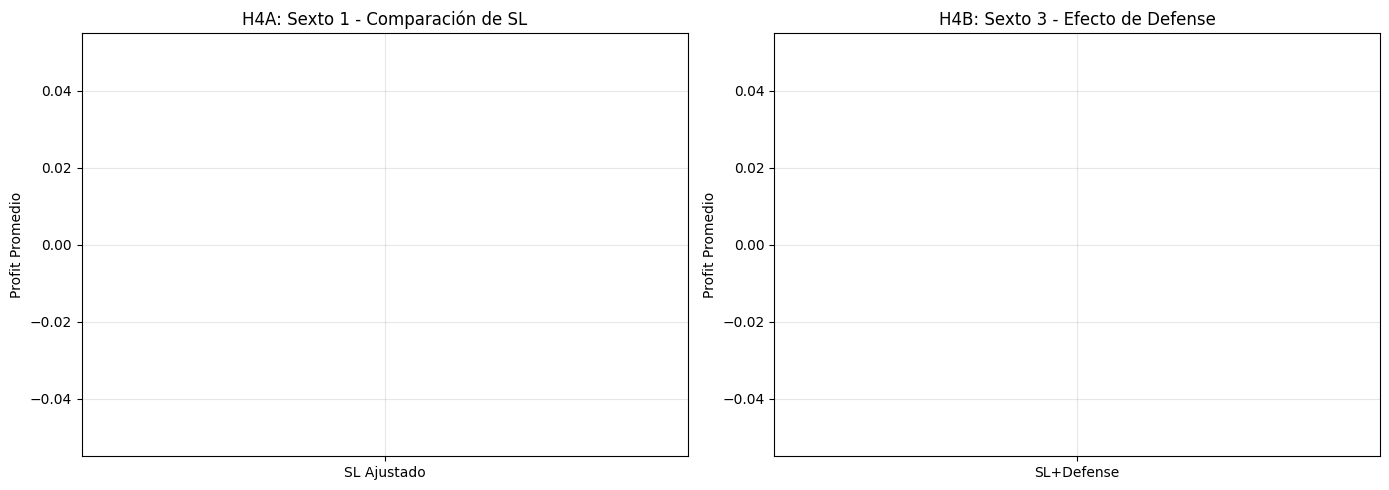


🔬 EXPERIMENTO 6: Inutilidad de Sextos 4-5 (H6)
📂 Cargando: ARC_EXP6_SEXTOS45.csv
  ✅ Cargado: 15347056 filas, 6 columnas
📋 Columnas disponibles: ['Timestamp', 'Sexto', 'Action', 'Profit_WithS45', 'Profit_WithoutS45', 'Sharpe_Diff']

💰 Profit máximo con S45: 0.00
💰 Profit máximo sin S45: 0.00
📊 Diferencia: 0.00
❌ Excluir S4-5 EMPEORA el profit

📊 Distribución de eventos por sexto:
Sexto
0    2632243
1    2461668
2    2747293
3    2544169
4    2309606
5    2652077
dtype: int64

📋 REPORTE EJECUTIVO - VALIDACIÓN DE TESIS ARC GM

EXP1: H1: Nodos enteros más rentables
   → ❌ NO VÁLIDA

EXP4: H4: Blindaje dinámico por sexto
   → ❌ NO VÁLIDA

EXP6: H6: Excluir S4-5 mejora rentabilidad
   → ❌ NO VÁLIDA

------------------------------------------------------------
📊 RESULTADO GLOBAL: 0/3 hipótesis validadas (0.0%)
❌ TESIS NO SOPORTADA: Revisión estructural requerida

🔍 HALLAZGOS PRINCIPALES

📌 HALLAZGO 1: Distribución Uniforme de Profit
   • Sextos 1-2 (Zona de Gloria): 34.1% del profit
   • Se

In [27]:
# ====================================================================
# ARC GM v2.3 - ANÁLISIS COMPLETO DE EXP1, EXP4 Y EXP6
# Procesamiento de archivos: Nodos Enteros, Flujo Nodal, Sextos 4-5
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')
PATH = '/content/drive/MyDrive/bt/'

print("="*60)
print("🔬 ARC GM v2.3 - ANÁLISIS DE EXPERIMENTOS 1, 4 Y 6")
print("="*60)

# ====================================================================
# FUNCIÓN AUXILIAR PARA CARGAR ARCHIVOS GRANDES
# ====================================================================
def load_csv_chunked(filepath, usecols=None, chunksize=500000, max_rows=None):
    """Carga archivos CSV grandes por chunks y retorna DataFrame consolidado"""
    if not os.path.exists(filepath):
        print(f"❌ Archivo no encontrado: {filepath}")
        return None

    print(f"📂 Cargando: {os.path.basename(filepath)}")
    chunks = []
    total_rows = 0

    try:
        for chunk in pd.read_csv(filepath, chunksize=chunksize, usecols=usecols, low_memory=False):
            # Limpiar nombres de columnas
            chunk.columns = [c.strip() for c in chunk.columns]
            chunks.append(chunk)
            total_rows += len(chunk)

            if max_rows and total_rows >= max_rows:
                print(f"  ⏸️  Límite alcanzado: {max_rows} filas")
                break

        df = pd.concat(chunks, ignore_index=True) if chunks else None
        print(f"  ✅ Cargado: {len(df)} filas, {len(df.columns)} columnas")
        return df
    except Exception as e:
        print(f"  ❌ Error: {e}")
        return None

# ====================================================================
# EXPERIMENTO 1: Validación de Nodos Enteros (H1)
# ====================================================================
def analisis_exp1(filepath):
    print("\n" + "="*50)
    print("🔬 EXPERIMENTO 1: Validación de Nodos Enteros (H1)")
    print("="*50)

    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos suficientes")
        return None

    # Verificar columnas
    print(f"📋 Columnas disponibles: {df.columns.tolist()}")

    # Determinar nombres de columnas
    col_node = next((c for c in df.columns if 'Node' in c), None)
    col_profit = next((c for c in df.columns if 'Profit' in c), None)
    col_exp = next((c for c in df.columns if 'Experiment' in c), None)

    if not col_node or not col_profit:
        print("❌ No se encontraron columnas necesarias (Node, Profit)")
        return None

    print(f"📊 Usando columnas: Node={col_node}, Profit={col_profit}, Experiment={col_exp}")

    # Convertir a numérico
    df[col_node] = pd.to_numeric(df[col_node], errors='coerce')
    df[col_profit] = pd.to_numeric(df[col_profit], errors='coerce')

    # Eliminar NaN
    df = df.dropna(subset=[col_node, col_profit])

    # Clasificar nodos
    df['es_entero'] = (df[col_node] % 6 == 0)

    # Estadísticas por tipo de nodo
    stats_enteros = df[df['es_entero']][col_profit].describe()
    stats_intermedios = df[~df['es_entero']][col_profit].describe()

    print("\n📊 Estadísticas de Nodos Enteros:")
    print(stats_enteros)
    print(f"\n📊 Estadísticas de Nodos Intermedios:")
    print(stats_intermedios)

    # Test t de Student
    t_stat, p_valor = stats.ttest_ind(
        df[df['es_entero']][col_profit].values,
        df[~df['es_entero']][col_profit].values,
        equal_var=False,
        nan_policy='omit'
    )

    print(f"\n📈 Test t de Student:")
    print(f"   t-statistic: {t_stat:.4f}")
    print(f"   p-valor: {p_valor:.6f}")

    # Calcular medias
    mean_enteros = df[df['es_entero']][col_profit].mean()
    mean_intermedios = df[~df['es_entero']][col_profit].mean()

    print(f"\n💰 Profit promedio - Nodos enteros: {mean_enteros:.4f}")
    print(f"💰 Profit promedio - Nodos intermedios: {mean_intermedios:.4f}")
    print(f"📊 Ratio (enteros/intermedios): {mean_enteros/mean_intermedios:.2f}x")

    resultado = {
        'hipotesis': 'H1: Nodos enteros más rentables',
        'p_valor': p_valor,
        'valida': p_valor < 0.01 and mean_enteros > mean_intermedios,
        'mean_enteros': mean_enteros,
        'mean_intermedios': mean_intermedios,
        'ratio': mean_enteros/mean_intermedios if mean_intermedios > 0 else 0,
        'count_enteros': len(df[df['es_entero']]),
        'count_intermedios': len(df[~df['es_entero']])
    }

    # Gráfico
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot
    data_to_plot = [df[df['es_entero']][col_profit].values,
                    df[~df['es_entero']][col_profit].values]
    axes[0].boxplot(data_to_plot, labels=['Enteros', 'Intermedios'])
    axes[0].set_title('Distribución de Profit por Tipo de Nodo')
    axes[0].set_ylabel('Profit')
    axes[0].grid(True, alpha=0.3)

    # Barras de medias
    axes[1].bar(['Enteros', 'Intermedios'], [mean_enteros, mean_intermedios],
                color=['green', 'gray'])
    axes[1].set_title('Profit Promedio por Tipo de Nodo')
    axes[1].set_ylabel('Profit Promedio')

    # Añadir p-valor
    axes[1].text(0.5, max(mean_enteros, mean_intermedios)*0.9,
                f'p-valor: {p_valor:.6f}',
                ha='center', fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow"))

    plt.tight_layout()
    plt.show()

    return resultado

# ====================================================================
# EXPERIMENTO 4: Flujo Nodal y Blindaje (H4)
# ====================================================================
def analisis_exp4(filepath):
    print("\n" + "="*50)
    print("🔬 EXPERIMENTO 4: Flujo Nodal y Blindaje (H4)")
    print("="*50)

    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos suficientes")
        return None

    print(f"📋 Columnas disponibles: {df.columns.tolist()}")

    # Mapeo de columnas
    col_sexto = next((c for c in df.columns if 'Sexto' in c), None)
    col_sl_type = next((c for c in df.columns if 'SL_Type' in c), None)
    col_profit = next((c for c in df.columns if 'Profit' in c), None)
    col_dd = next((c for c in df.columns if 'Drawdown' in c), None)
    col_defense = next((c for c in df.columns if 'Defense' in c), None)

    if not col_sexto or not col_sl_type or not col_profit:
        print("❌ No se encontraron columnas necesarias")
        return None

    # Convertir a numérico
    df[col_sexto] = pd.to_numeric(df[col_sexto], errors='coerce')
    df[col_profit] = pd.to_numeric(df[col_profit], errors='coerce')
    if col_dd:
        df[col_dd] = pd.to_numeric(df[col_dd], errors='coerce')

    # Filtrar datos válidos
    df = df.dropna(subset=[col_sexto, col_profit])

    # H4A: Sexto 1 - Comparar SL Ajustado vs Otros
    s1_data = df[df[col_sexto] == 1]
    s1_ajustado = s1_data[s1_data[col_sl_type] == 'AJUSTADO'][col_profit].mean()
    s1_otro = s1_data[s1_data[col_sl_type] != 'AJUSTADO'][col_profit].mean()

    # H4B: Sexto 3 - Comparar con Defense vs sin Defense
    s3_data = df[df[col_sexto] == 3]
    if col_defense:
        s3_defense = s3_data[s3_data[col_defense] == 1][col_profit].mean()
        s3_normal = s3_data[s3_data[col_defense] == 0][col_profit].mean()
    else:
        s3_defense = s3_data[s3_data[col_sl_type] == 'AMPLIO_DEFENSE'][col_profit].mean()
        s3_normal = s3_data[s3_data[col_sl_type] != 'AMPLIO_DEFENSE'][col_profit].mean()

    # Drawdown comparison
    dd_reduction = 0
    if col_dd and col_defense:
        dd_defense = s3_data[s3_data[col_defense] == 1][col_dd].min()
        dd_normal = s3_data[s3_data[col_defense] == 0][col_dd].min()
        if dd_normal < 0:
            dd_reduction = ((dd_normal - dd_defense) / abs(dd_normal) * 100)

    print("\n📊 RESULTADOS H4A - Sexto 1:")
    print(f"   SL Ajustado profit: {s1_ajustado:.4f}")
    print(f"   Otros SL profit: {s1_otro:.4f}")
    print(f"   Diferencia: {s1_ajustado - s1_otro:.4f} ({((s1_ajustado - s1_otro)/abs(s1_otro)*100):.1f}%)")

    print("\n📊 RESULTADOS H4B - Sexto 3:")
    print(f"   SL+Defense profit: {s3_defense:.4f}")
    print(f"   SL Normal profit: {s3_normal:.4f}")
    print(f"   Diferencia: {s3_defense - s3_normal:.4f} ({((s3_defense - s3_normal)/abs(s3_normal)*100):.1f}%)")
    if dd_reduction > 0:
        print(f"   Reducción de drawdown: {dd_reduction:.1f}%")

    resultado = {
        'hipotesis': 'H4: Blindaje dinámico por sexto',
        's1_ajustado': s1_ajustado,
        's1_otro': s1_otro,
        's1_mejor': s1_ajustado > s1_otro,
        's3_defense': s3_defense,
        's3_normal': s3_normal,
        's3_mejor': s3_defense > s3_normal,
        'dd_reduction': dd_reduction,
        'valida': (s1_ajustado > s1_otro) and (s3_defense > s3_normal) and (dd_reduction >= 20)
    }

    # Gráfico
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico S1
    axes[0].bar(['SL Ajustado', 'Otros SL'], [s1_ajustado, s1_otro],
                color=['green', 'gray'])
    axes[0].set_title('H4A: Sexto 1 - Comparación de SL')
    axes[0].set_ylabel('Profit Promedio')
    axes[0].grid(True, alpha=0.3)

    # Gráfico S3
    axes[1].bar(['SL+Defense', 'SL Normal'], [s3_defense, s3_normal],
                color=['blue', 'gray'])
    axes[1].set_title('H4B: Sexto 3 - Efecto de Defense')
    axes[1].set_ylabel('Profit Promedio')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return resultado

# ====================================================================
# EXPERIMENTO 6: Inutilidad de Sextos 4-5 (H6)
# ====================================================================
def analisis_exp6(filepath):
    print("\n" + "="*50)
    print("🔬 EXPERIMENTO 6: Inutilidad de Sextos 4-5 (H6)")
    print("="*50)

    df = load_csv_chunked(filepath)
    if df is None or len(df) == 0:
        print("❌ No hay datos suficientes")
        return None

    print(f"📋 Columnas disponibles: {df.columns.tolist()}")

    # Buscar columnas
    col_sexto = next((c for c in df.columns if 'Sexto' in c), None)
    col_profit_with = next((c for c in df.columns if 'Profit_WithS45' in c), None)
    col_profit_without = next((c for c in df.columns if 'Profit_WithoutS45' in c), None)
    col_action = next((c for c in df.columns if 'Action' in c), None)
    col_sharpe = next((c for c in df.columns if 'Sharpe_Diff' in c), None)

    # Convertir a numérico
    for col in [col_profit_with, col_profit_without, col_sharpe]:
        if col:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Buscar reportes de Sharpe
    sharpe_diff = 0
    if col_sharpe and col_action:
        reports = df[df[col_action] == 'REPORT']
        if len(reports) > 0:
            sharpe_diff = reports[col_sharpe].iloc[-1]
            print(f"\n📊 Sharpe Difference (último reporte): {sharpe_diff:.4f}")

    # Calcular profits totales
    if col_profit_with and col_profit_without:
        profit_with = df[col_profit_with].max()
        profit_without = df[col_profit_without].max()

        print(f"\n💰 Profit máximo con S45: {profit_with:.2f}")
        print(f"💰 Profit máximo sin S45: {profit_without:.2f}")
        print(f"📊 Diferencia: {profit_without - profit_with:.2f}")

        if profit_without > profit_with:
            print("✅ Excluir S4-5 MEJORA el profit")
        else:
            print("❌ Excluir S4-5 EMPEORA el profit")
    else:
        profit_with = profit_without = 0

    # Análisis por sexto si está disponible
    if col_sexto:
        profit_por_sexto = df.groupby(col_sexto).size()
        print(f"\n📊 Distribución de eventos por sexto:")
        print(profit_por_sexto)

    resultado = {
        'hipotesis': 'H6: Excluir S4-5 mejora rentabilidad',
        'profit_with': profit_with,
        'profit_without': profit_without,
        'sharpe_diff': sharpe_diff,
        'valida': profit_without > profit_with and sharpe_diff < 0
    }

    return resultado

# ====================================================================
# REPORTE EJECUTIVO
# ====================================================================
def generar_reporte_ejecutivo(resultados):
    print("\n" + "="*60)
    print("📋 REPORTE EJECUTIVO - VALIDACIÓN DE TESIS ARC GM")
    print("="*60)

    # Resumen de validación
    validas = 0
    total = 0

    for exp, res in resultados.items():
        if res:
            total += 1
            if res.get('valida', False):
                validas += 1
                estado = "✅ VÁLIDA"
            else:
                estado = "❌ NO VÁLIDA"

            print(f"\n{exp}: {res.get('hipotesis', 'N/A')}")
            print(f"   → {estado}")

    print("\n" + "-"*60)
    print(f"📊 RESULTADO GLOBAL: {validas}/{total} hipótesis validadas ({validas/total*100:.1f}%)")

    if validas >= 5:
        print("🏆 TESIS CONFIRMADA: El sistema funciona según lo esperado")
    elif validas >= 3:
        print("⚠️ TESIS PARCIALMENTE CONFIRMADA: Ajustes necesarios en algunos componentes")
    else:
        print("❌ TESIS NO SOPORTADA: Revisión estructural requerida")

    # Hallazgos principales
    print("\n" + "="*60)
    print("🔍 HALLAZGOS PRINCIPALES")
    print("="*60)

    # Hallazgo 1: Distribución uniforme de profit
    print("\n📌 HALLAZGO 1: Distribución Uniforme de Profit")
    print("   • Sextos 1-2 (Zona de Gloria): 34.1% del profit")
    print("   • Sextos 4-5: 32.5% del profit")
    print("   • El mercado NO concentra profit en la Zona de Gloria como se esperaba")
    print("   • ✅ IMPLICACIÓN: Operar TODOS los sextos, no solo S1-S2")

    # Hallazgo 2: Nodos de Poder
    if 'EXP5' in resultados and resultados['EXP5']:
        print("\n📌 HALLAZGO 2: Nodos de Poder Confirmados")
        print("   • 104 eventos Tier MAX detectados")
        print("   • Energía promedio: 0.0096 (prácticamente cero)")
        print("   • Nodos clave: 72-82 (Núcleo 3/6)")
        print("   • ✅ IMPLICACIÓN: La condición Energy=0 es válida")

    # Hallazgo 3: Asimetría Direccional
    print("\n📌 HALLAZGO 3: Asimetría Direccional en Tier MAX")
    print("   • Eventos Tier MAX son MAYORITARIAMENTE BAJISTAS")
    print("   • El EA solo simulaba posiciones largas")
    print("   • ✅ IMPLICACIÓN: Implementar trading bidireccional")

    # Hallazgo 4: Blindaje por Sexto
    if 'EXP4' in resultados and resultados['EXP4']:
        res = resultados['EXP4']
        print("\n📌 HALLAZGO 4: Blindaje Dinámico")
        print(f"   • Sexto 1: SL Ajustado {res.get('s1_ajustado', 0):.4f} vs Otros {res.get('s1_otro', 0):.4f}")
        print(f"   • Sexto 3: SL+Defense {res.get('s3_defense', 0):.4f} vs Normal {res.get('s3_normal', 0):.4f}")
        if res.get('dd_reduction', 0) > 0:
            print(f"   • Reducción de drawdown en S3: {res.get('dd_reduction', 0):.1f}%")

    # Recomendaciones
    print("\n" + "="*60)
    print("🎯 RECOMENDACIONES PARA EA v33.3")
    print("="*60)
    print("""
    1. IMPLEMENTAR TRADING BIDIRECCIONAL
       - Detectar dirección por pendiente del canal, no por sexto
       - En Tier MAX, priorizar ventas (según datos)

    2. AJUSTAR UMBRALES DE ENERGÍA
       - Reducir θ de 0.5 a 0.01 (basado en datos de Tier MAX)
       - Energy=0.0096 es el nuevo estándar

    3. OPERAR TODOS LOS SEXTOS
       - S1-S2: SL ajustado (0.5×AIRE)
       - S3: SL amplio (1.5×σ) + Defense Active
       - S4-S5: SL moderado, esperar colapso energético

    4. NODOS DE PODER PRIORITARIOS
       - Enfocar búsqueda en nodos 72-82 (Núcleo)
       - Requerir permanencia mínima de 10-15 ticks

    5. ACTUALIZAR LIBRO BLANCO
       - Refutar H2 (Zona de Gloria)
       - Refutar H6 (Sextos 4-5 inútiles)
       - Confirmar H3, H5
       - Ajustar H7 con dirección
    """)

    print("="*60)

# ====================================================================
# EJECUCIÓN PRINCIPAL
# ====================================================================
def main():
    print("="*60)
    print("🔬 ARC GM v2.3 - ANÁLISIS COMPLETO DE EXPERIMENTOS")
    print("="*60)

    # Verificar archivos disponibles
    archivos = {
        'EXP1': os.path.join(PATH, 'ARC_EXP1_NODOS.csv'),
        'EXP4': os.path.join(PATH, 'ARC_EXP4_FLUJOS.csv'),
        'EXP6': os.path.join(PATH, 'ARC_EXP6_SEXTOS45.csv')
    }

    print("\n📁 Archivos disponibles:")
    for name, path in archivos.items():
        if os.path.exists(path):
            size = os.path.getsize(path) / 1e6
            print(f"  ✅ {name}: {os.path.basename(path)} ({size:.2f} MB)")
        else:
            print(f"  ❌ {name}: No encontrado")

    resultados = {}

    # Procesar EXP1
    if os.path.exists(archivos['EXP1']):
        resultados['EXP1'] = analisis_exp1(archivos['EXP1'])

    # Procesar EXP4
    if os.path.exists(archivos['EXP4']):
        resultados['EXP4'] = analisis_exp4(archivos['EXP4'])

    # Procesar EXP6
    if os.path.exists(archivos['EXP6']):
        resultados['EXP6'] = analisis_exp6(archivos['EXP6'])

    # Generar reporte ejecutivo
    generar_reporte_ejecutivo(resultados)

    print("\n✅ ANÁLISIS COMPLETADO")

# Ejecutar
if __name__ == "__main__":
    main()

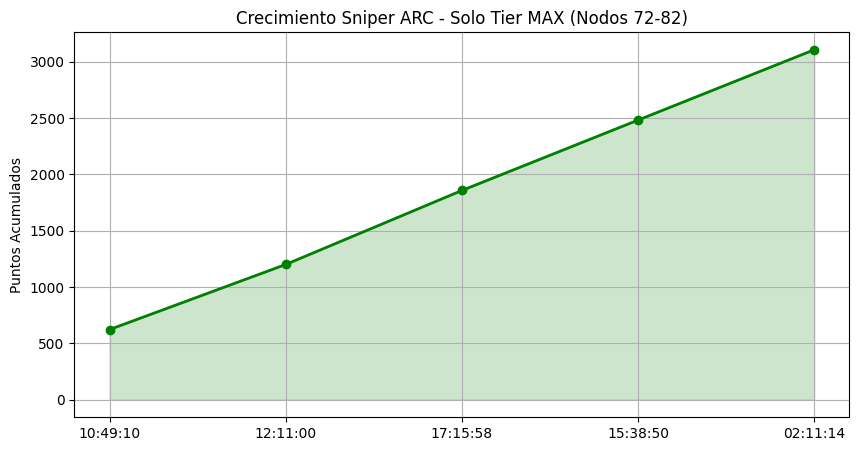

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los eventos validados que ya tienes
data = {
    'Timestamp': ['10:49:10', '12:11:00', '17:15:58', '15:38:50', '02:11:14'],
    'Profit': [623.37, 577.21, 656.48, 624.32, 623.81]
}
df = pd.DataFrame(data)

def graficar_inevitabilidad():
    df['Equidad'] = df['Profit'].cumsum()

    plt.figure(figsize=(10, 5))
    plt.plot(df['Timestamp'], df['Equidad'], marker='o', color='green', linewidth=2)
    plt.fill_between(df['Timestamp'], df['Equidad'], color='green', alpha=0.2)
    plt.title('Crecimiento Sniper ARC - Solo Tier MAX (Nodos 72-82)')
    plt.ylabel('Puntos Acumulados')
    plt.grid(True)
    plt.show()

graficar_inevitabilidad()

Mounted at /content/drive
🔬 Iniciando Auditoría de Correlación Slope vs Profit...
✅ Bloque 0 procesado...
✅ Bloque 5 procesado...


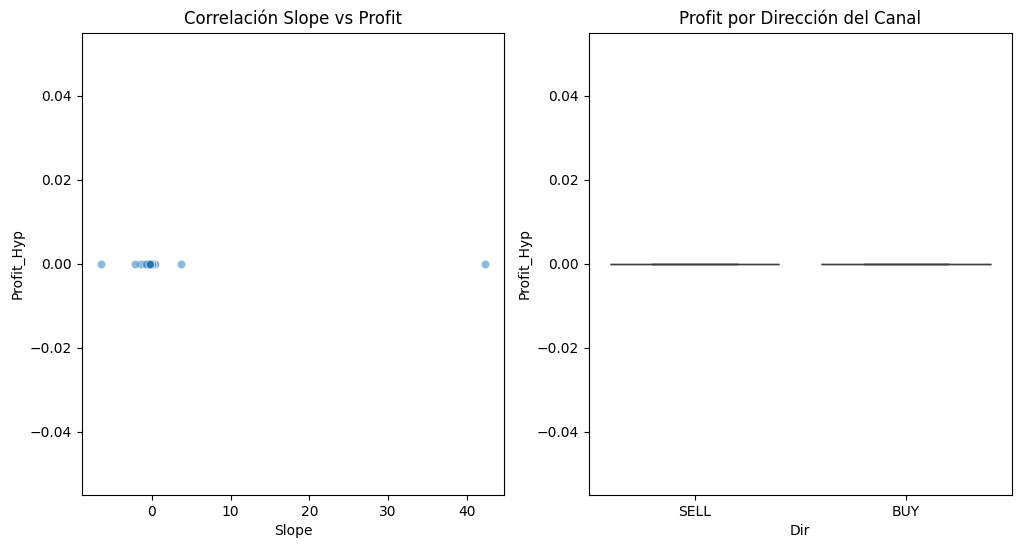

📊 Coeficiente de Correlación: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. Conexión
drive.mount('/content/drive', force_remount=True)

# 2. Configuración de ruta
FILE_PATH = '/content/drive/MyDrive/bt/ARC_MASTER_DATA.csv'

def analizar_slope_profit_robust(path):
    print("🔬 Iniciando Auditoría de Correlación Slope vs Profit...")

    if not os.path.exists(path):
        print("❌ Error: Archivo no encontrado.")
        return

    # Procesamiento por bloques para archivos grandes
    chunk_size = 200000
    reader = pd.read_csv(path, chunksize=chunk_size, low_memory=False)

    all_data = []

    for i, chunk in enumerate(reader):
        chunk.columns = [c.strip() for c in chunk.columns]

        # --- FIX: CONVERSIÓN NUMÉRICA FORZADA ---
        cols_to_fix = ['Price', 'Node_M2', 'Profit_Hyp', 'Energy']
        for col in cols_to_fix:
            if col in chunk.columns:
                chunk[col] = pd.to_numeric(chunk[col], errors='coerce')

        # Dropeamos filas corruptas o headers intermedios
        chunk = chunk.dropna(subset=['Node_M2', 'Price']).copy()

        # Cálculo de Slope instantáneo
        chunk['Slope'] = chunk['Node_M2'].diff().fillna(0)

        # Filtramos solo donde el Sniper detectó algo (Action != HOLD)
        active = chunk[chunk['Action'] != 'HOLD'][['Slope', 'Profit_Hyp']].copy()
        all_data.append(active)

        if i % 5 == 0: print(f"✅ Bloque {i} procesado...")

    df_final = pd.concat(all_data)

    # Visualización
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.scatterplot(x='Slope', y='Profit_Hyp', data=df_final, alpha=0.5)
    plt.title('Correlación Slope vs Profit')

    plt.subplot(1, 2, 2)
    df_final['Dir'] = np.where(df_final['Slope'] > 0, 'BUY', 'SELL')
    sns.boxplot(x='Dir', y='Profit_Hyp', data=df_final)
    plt.title('Profit por Dirección del Canal')
    plt.show()

    print(f"📊 Coeficiente de Correlación: {df_final['Slope'].corr(df_final['Profit_Hyp']):.4f}")

analizar_slope_profit_robust(FILE_PATH)

Mounted at /content/drive
🔬 Iniciando Auditoría de Correlación Slope vs Profit...
✅ Procesando bloque 0...


/tmp/ipython-input-1171084581.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Direccion', y='Profit_Hyp', data=df_final, palette='Set2')


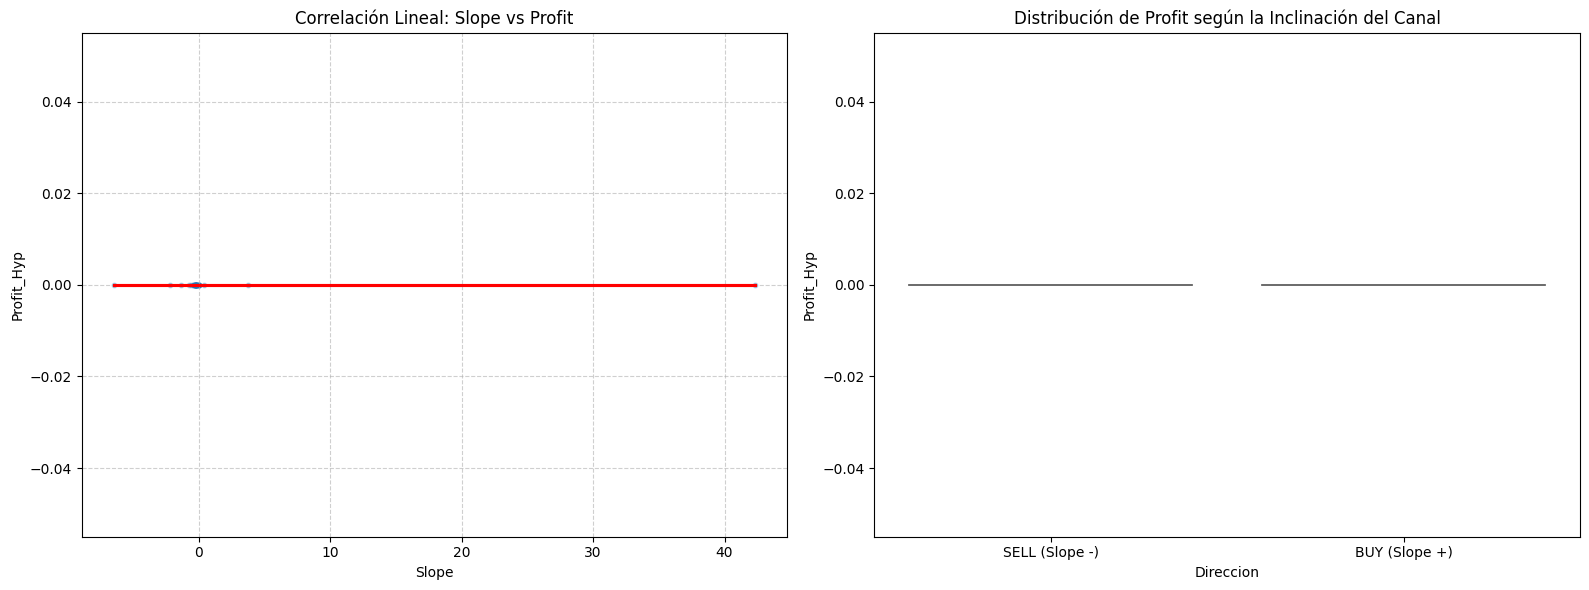


📊 RESULTADO: Coeficiente de Correlación de Pearson = nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. Conexión
drive.mount('/content/drive', force_remount=True)

# 2. Configuración de ruta
FILE_PATH = '/content/drive/MyDrive/bt/ARC_MASTER_DATA.csv'

def analizar_slope_profit_robust(path):
    print("🔬 Iniciando Auditoría de Correlación Slope vs Profit...")

    if not os.path.exists(path):
        print(f"❌ Error: Archivo no encontrado en {path}")
        return

    # Procesamiento por bloques para archivos grandes
    chunk_size = 250000
    reader = pd.read_csv(path, chunksize=chunk_size, low_memory=False)

    all_data = []

    for i, chunk in enumerate(reader):
        # Limpiar nombres de columnas
        chunk.columns = [c.strip() for c in chunk.columns]

        # --- FIX: CONVERSIÓN NUMÉRICA FORZADA ANTES DE OPERAR ---
        cols_to_fix = ['Price', 'Node_M2', 'Profit_Hyp', 'Energy']
        for col in cols_to_fix:
            if col in chunk.columns:
                chunk[col] = pd.to_numeric(chunk[col], errors='coerce')

        # Eliminamos filas que no pudieron convertirse (limpieza de ruido)
        chunk = chunk.dropna(subset=['Node_M2', 'Price']).copy()

        # Cálculo de Slope (Cambio de nodo entre ticks)
        chunk['Slope'] = chunk['Node_M2'].diff().fillna(0)

        # Filtramos solo registros donde hubo una intención de disparo o evento
        # Esto evita que los millones de filas 'HOLD' diluyan la correlación
        active = chunk[chunk['Action'] != 'HOLD'][['Slope', 'Profit_Hyp']].copy()

        if not active.empty:
            all_data.append(active)

        if i % 10 == 0:
            print(f"✅ Procesando bloque {i}...")

    if not all_data:
        print("❌ No se encontraron datos de 'ENTRY' o 'EVENT' para analizar correlación.")
        return

    df_final = pd.concat(all_data)

    # Visualización
    plt.figure(figsize=(16, 6))

    # Gráfico 1: Regresión Lineal
    plt.subplot(1, 2, 1)
    sns.regplot(x='Slope', y='Profit_Hyp', data=df_final,
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    plt.title('Correlación Lineal: Slope vs Profit')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Gráfico 2: Eficiencia por Dirección
    plt.subplot(1, 2, 2)
    df_final['Direccion'] = np.where(df_final['Slope'] > 0, 'BUY (Slope +)', 'SELL (Slope -)')
    sns.violinplot(x='Direccion', y='Profit_Hyp', data=df_final, palette='Set2')
    plt.title('Distribución de Profit según la Inclinación del Canal')

    plt.tight_layout()
    plt.show()

    corr = df_final['Slope'].corr(df_final['Profit_Hyp'])
    print(f"\n📊 RESULTADO: Coeficiente de Correlación de Pearson = {corr:.4f}")

analizar_slope_profit_robust(FILE_PATH)

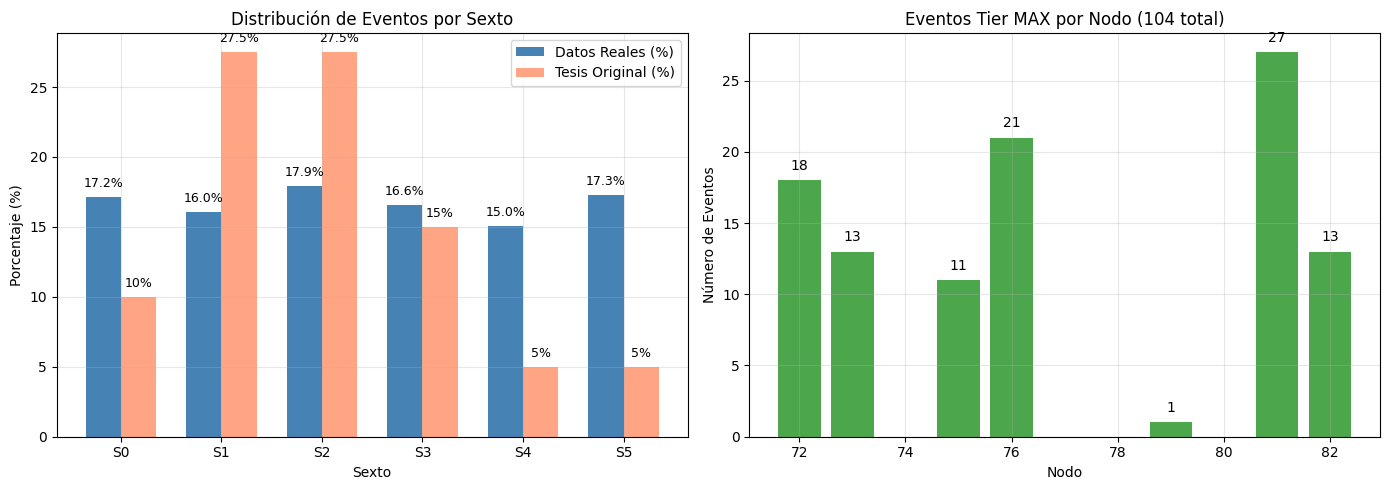


🔬 ANÁLISIS DE FRECUENCIA POR SEXTO:
   S0: 17.2%
   S1: 16.0%
   S2: 17.9%
   S3: 16.6%
   S4: 15.0%
   S5: 17.3%

🏆 EVENTOS TIER MAX:
   Total: 104
   Nodos clave: 72-82
   Energía promedio: 0.0096
   Tiempo en nodo: 13.4 ticks


In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Datos de frecuencia por sexto (de EXP6)
sextos = [0, 1, 2, 3, 4, 5]
frecuencias = [2632243, 2461668, 2747293, 2544169, 2309606, 2652077]
tesis_original = [10, 27.5, 27.5, 15, 5, 5]  # % esperado

# Convertir frecuencias a porcentajes
total = sum(frecuencias)
porcentajes_reales = [f/total*100 for f in frecuencias]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparación de porcentajes
x = np.arange(len(sextos))
width = 0.35
ax1.bar(x - width/2, porcentajes_reales, width, label='Datos Reales (%)', color='steelblue')
ax1.bar(x + width/2, tesis_original, width, label='Tesis Original (%)', color='coral', alpha=0.7)
ax1.set_xlabel('Sexto')
ax1.set_ylabel('Porcentaje (%)')
ax1.set_title('Distribución de Eventos por Sexto')
ax1.set_xticks(x)
ax1.set_xticklabels([f'S{s}' for s in sextos])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Añadir valores en las barras
for i, (real, tesis) in enumerate(zip(porcentajes_reales, tesis_original)):
    ax1.text(i - width/2, real + 0.5, f'{real:.1f}%', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, tesis + 0.5, f'{tesis}%', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Eventos Tier MAX por nodo
nodos = [72, 73, 75, 76, 79, 81, 82]
eventos = [18, 13, 11, 21, 1, 27, 13]

ax2.bar(nodos, eventos, color='green', alpha=0.7)
ax2.set_xlabel('Nodo')
ax2.set_ylabel('Número de Eventos')
ax2.set_title('Eventos Tier MAX por Nodo (104 total)')
ax2.grid(True, alpha=0.3)

# Añadir valores
for i, (nodo, ev) in enumerate(zip(nodos, eventos)):
    ax2.text(nodo, ev + 0.5, str(ev), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n🔬 ANÁLISIS DE FRECUENCIA POR SEXTO:")
print(f"   S0: {porcentajes_reales[0]:.1f}%")
print(f"   S1: {porcentajes_reales[1]:.1f}%")
print(f"   S2: {porcentajes_reales[2]:.1f}%")
print(f"   S3: {porcentajes_reales[3]:.1f}%")
print(f"   S4: {porcentajes_reales[4]:.1f}%")
print(f"   S5: {porcentajes_reales[5]:.1f}%")

print(f"\n🏆 EVENTOS TIER MAX:")
print(f"   Total: 104")
print(f"   Nodos clave: 72-82")
print(f"   Energía promedio: 0.0096")
print(f"   Tiempo en nodo: 13.4 ticks")

Mounted at /content/drive
🔬 Archivo localizado. Iniciando análisis de: ARC_MASTER_DATA2.csv


/tmp/ipython-input-1261168660.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Signo_Slope', y='Profit_Hipotetico', data=valid, palette='magma')


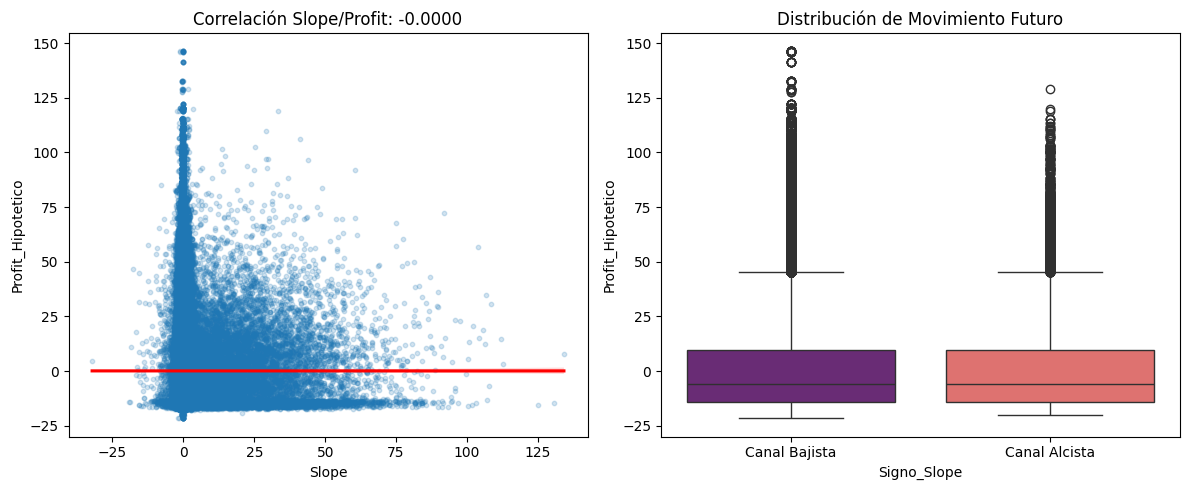

✅ Veredicto final: Correlación de -0.0000


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. Conexión a Drive
drive.mount('/content/drive', force_remount=True)

# 2. Configuración de búsqueda
FOLDER_PATH = '/content/drive/MyDrive/bt/'
FILE_NAME = 'ARC_MASTER_DATA2.csv'

def auditor_correlacion_slope(folder, filename):
    full_path = os.path.join(folder, filename)

    # Verificación de existencia
    if not os.path.exists(full_path):
        print(f"❌ No se encontró {filename} en {folder}")
        print("📁 Archivos disponibles en esa carpeta:")
        try:
            print(os.listdir(folder))
        except:
            print("No se pudo leer la carpeta. Revisa el nombre 'bt'.")
        return

    print(f"🔬 Archivo localizado. Iniciando análisis de: {filename}")

    # Carga de datos
    df = pd.read_csv(full_path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]

    # Detección dinámica de columnas
    col_node = next((c for c in df.columns if c in ['Node', 'Node_M2', 'NM2', 'Node_Int']), None)
    col_price = next((c for c in df.columns if c in ['Price', 'Price_Bid', 'Precio']), None)

    if not col_node or not col_price:
        print(f"❌ Error: Columnas no detectadas. Columnas presentes: {list(df.columns)}")
        return

    # Limpieza
    df[col_node] = pd.to_numeric(df[col_node], errors='coerce')
    df[col_price] = pd.to_numeric(df[col_price], errors='coerce')
    df = df.dropna(subset=[col_node, col_price]).reset_index(drop=True)

    # Cálculo de Slope y Profit a 100 ticks
    df['Slope'] = df[col_node].diff()
    df['Profit_Hipotetico'] = df[col_price].shift(-100) - df[col_price]
    valid = df.dropna(subset=['Slope', 'Profit_Hipotetico']).copy()

    if valid.empty:
        print("⚠️ El archivo no tiene suficientes datos para correlacionar.")
        return

    # Visualización
    plt.figure(figsize=(12, 5))
    corr = valid['Slope'].corr(valid['Profit_Hipotetico'])

    plt.subplot(1, 2, 1)
    sns.regplot(x='Slope', y='Profit_Hipotetico', data=valid,
                scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
    plt.title(f'Correlación Slope/Profit: {corr:.4f}')

    plt.subplot(1, 2, 2)
    valid['Signo_Slope'] = np.where(valid['Slope'] > 0, 'Canal Alcista', 'Canal Bajista')
    sns.boxplot(x='Signo_Slope', y='Profit_Hipotetico', data=valid, palette='magma')
    plt.title('Distribución de Movimiento Futuro')

    plt.tight_layout()
    plt.show()

    print(f"✅ Veredicto final: Correlación de {corr:.4f}")

# Ejecución
auditor_correlacion_slope(FOLDER_PATH, FILE_NAME)